<a href="https://colab.research.google.com/github/Michael-M-William/ML-Final-project/blob/michael/Final_project_backup3_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NASA RAW DATA

              
                          │
              
                          ▼
           
                 1. DATA AUDIT
                          │
                          ▼
              2. DATA CLEANING
             - Missing values
             - Invalid values
             - Duplicates
             - IDs / metadata
                          │
                          ▼
              3. DEFINE TARGET
                  pha: N / Y
                          │
                          ▼
             4. TRAIN / VAL / TEST
              70%       15%       15%
               │          │         │
               ▼          ▼         ▼
             TRAIN      VALID      TEST
               │          │         │
               └──────────┴─────────┘
                    NO INFORMATION
                    LEAKAGE BETWEEN
                    SPLITS
                          │
                          ▼
             5. FEATURE ENGINEERING
             Create meaningful orbital
             / physical features
                          │
                          ▼
             6. FEATURE SELECTION
             Select useful features
                          │
                          ▼
             7. PREPROCESSING
             Imputation / Scaling
                          │
                          ▼
             8. PCA EXPERIMENT
             Optional dimensionality
             reduction
                          │
                          ▼
             9. IMBALANCE HANDLING
             ┌────────────┬─────────────┐
             │            │             │
           SMOTE     Class Weight   UnderSampling
             │            │             │
             └────────────┴─────────────┘
                          │
                          ▼
             10. MODEL TRAINING
             LR / SVM / RF / GB /
             XGBoost / etc.
                          │
                          ▼
             11. VALIDATION
             Compare models
                          │
                          ▼
             12. THRESHOLD TUNING
             0.30 / 0.40 / 0.50 / ...
                          │
                          ▼
             13. FINAL MODEL
                          │
                          ▼
             14. TEST ONCE
             Final untouched test set
                          │
                          ▼
             15. FINAL EVALUATION
             Recall / Precision / F1
             ROC-AUC / PR-AUC
             Confusion Matrix




Train

نقدر نعمل عليه:

Imputation
Scaling
Feature Selection
PCA
SMOTE
Class Weight
Undersampling
Model Training


Validation

نستخدمه في:

Model comparison
Threshold tuning
Hyperparameter decisions

لكن لا نعمل عليه SMOTE.

Test

يُترك untouched تمامًا لحد آخر خطوة.

المتغيرات

TARGET

numeric_cols

categorical_cols


# inport lips and data

In [196]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import SelectFromModel

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)

from sklearn.linear_model import LogisticRegression

from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve
)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler


In [197]:
df=pd.read_csv('https://gitlab.com/mirsakhawathossain/pha-ml/-/raw/master/Dataset/dataset.csv')
display(df.head(2))

,id,spkid,full_name,pdes,name,prefix,neo,pha,H,diameter,albedo,diameter_sigma,orbit_id,epoch,epoch_mjd,epoch_cal,equinox,e,a,q,i,om,w,ma,ad,n,tp,tp_cal,per,per_y,moid,moid_ld,sigma_e,sigma_a,sigma_q,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,a0000001,2000001,1 Ceres,1,Ceres,NaN,N,N,3.4,939.4,0.090,0.2,JPL 47,2458600.5,58600,20190427.0,J2000,0.076009,2.769165,2.558684,10.594067,80.305531,73.597695,77.372098,2.979647,0.213885,2.458239e+06,2.018043e+07,1683.145703,4.608202,1.59478,620.640533,4.819000e-12,1.032800e-11,1.956900e-11,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,MBA,0.43301
1,a0000002,2000002,2 Pallas,2,Pallas,NaN,N,N,4.2,545.0,0.101,18.0,JPL 37,2459000.5,59000,20200531.0,J2000,0.229972,2.773841,2.135935,34.832932,173.024741,310.202392,144.975675,3.411748,0.213345,2.458321e+06,2.018072e+07,1687.410992,4.619880,1.23429,480.348639,3.193400e-08,4.033700e-09,8.832200e-08,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,MBA,0.35936


In [198]:
ID_COLUMNS = [
    "id",
    "spkid",
    "pdes",
    "name",
    "full_name",
    "orbit_id",
    "epoch_cal",
    "prefix",
    'equinox']
existing_id_columns = [
    col for col in ID_COLUMNS
    if col in df.columns]

df = df.drop( columns=existing_id_columns)
print(df.shape)

(958524, 36)


# EDA


---



1.   numirical view



In [199]:
RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
print(df.shape)
display(df.head())


(958524, 36)


,neo,pha,H,diameter,albedo,diameter_sigma,epoch,epoch_mjd,e,a,q,i,om,w,ma,ad,n,tp,tp_cal,per,per_y,moid,moid_ld,sigma_e,sigma_a,sigma_q,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,N,N,3.40,939.400,0.0900,0.200,2458600.5,58600,0.076009,2.769165,2.558684,10.594067,80.305531,73.597695,77.372098,2.979647,0.213885,2.458239e+06,2.018043e+07,1683.145703,4.608202,1.59478,620.640533,4.819000e-12,1.032800e-11,1.956900e-11,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,MBA,0.43301
1,N,N,4.20,545.000,0.1010,18.000,2459000.5,59000,0.229972,2.773841,2.135935,34.832932,173.024741,310.202392,144.975675,3.411748,0.213345,2.458321e+06,2.018072e+07,1687.410992,4.619880,1.23429,480.348639,3.193400e-08,4.033700e-09,8.832200e-08,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,MBA,0.35936
2,N,N,5.33,246.596,0.2140,10.594,2459000.5,59000,0.256936,2.668285,1.982706,12.991043,169.851482,248.066193,125.435355,3.353865,0.226129,2.458446e+06,2.018112e+07,1592.013769,4.358696,1.03429,402.514639,3.052000e-08,3.471800e-09,8.139200e-08,3.223100e-06,1.664600e-05,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,MBA,0.33848
3,N,N,3.00,525.400,0.4228,0.200,2458600.5,58600,0.088721,2.361418,2.151909,7.141771,103.810804,150.728541,95.861938,2.570926,0.271609,2.458248e+06,2.018051e+07,1325.432763,3.628837,1.13948,443.451432,2.332100e-10,1.514300e-09,1.928600e-09,2.170600e-07,3.880800e-07,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,MBA,0.39980
4,N,N,6.90,106.699,0.2740,3.140,2459000.5,59000,0.190913,2.574037,2.082619,5.367427,141.571026,358.648418,17.846343,3.065455,0.238661,2.458926e+06,2.020032e+07,1508.414421,4.129814,1.09575,426.433027,2.373700e-08,3.970900e-09,6.092400e-08,2.740800e-06,2.894900e-05,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,MBA,0.52191


In [200]:
# Target
TARGET = "pha"

# Numerical columns
numeric_cols = df.select_dtypes(
    include=np.number
).columns.tolist()

# Categorical columns
categorical_cols = df.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

categorical_cols = [col for col in categorical_cols if col != TARGET]

print("Numerical columns:")
print(numeric_cols)
print("\nNumber of numerical columns:", len(numeric_cols))

print("\nCategorical columns:")
print(categorical_cols)
print("\nNumber of categorical columns:", len(categorical_cols))

Numerical columns:
['H', 'diameter', 'albedo', 'diameter_sigma', 'epoch', 'epoch_mjd', 'e', 'a', 'q', 'i', 'om', 'w', 'ma', 'ad', 'n', 'tp', 'tp_cal', 'per', 'per_y', 'moid', 'moid_ld', 'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w', 'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per', 'rms']

Number of numerical columns: 33

Categorical columns:
['neo', 'class']

Number of categorical columns: 2


In [201]:
audit = pd.DataFrame({
    "Data_Type": df.dtypes.astype(str),
    "Missing_Count": df.isna().sum(),
    "Missing_Percentage": (
        df.isna().mean() * 100
    ).round(2),
    "Unique_Values": df.nunique(dropna=True)
})

audit = audit.sort_values(
    "Missing_Percentage",
    ascending=False
)

display(audit)

audit.to_csv(
    "data_quality_report.csv",
    index=True
)

,Data_Type,Missing_Count,Missing_Percentage,Unique_Values
albedo,float64,823421,85.91,1057
diameter_sigma,float64,822443,85.80,3054
diameter,float64,822315,85.79,16591
pha,object,19921,2.08,2
sigma_w,float64,19922,2.08,262719
sigma_ma,float64,19922,2.08,266816
sigma_om,float64,19922,2.08,223155
sigma_i,float64,19922,2.08,215741
sigma_n,float64,19922,2.08,251750
sigma_ad,float64,19926,2.08,269241


In [202]:

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

print("done")

done


In [203]:

duplicate_count = df.duplicated().sum()
duplicate_percentage = duplicate_count / len(df) * 100

print(f"Duplicate rows     : {duplicate_count:,}")
print(f"Duplicate %        : {duplicate_percentage:.4f}%")
print(f"Unique rows        : {df.drop_duplicates().shape[0]:,}")

Duplicate rows     : 0
Duplicate %        : 0.0000%
Unique rows        : 958,524


In [204]:
target_counts = df[TARGET].value_counts()

if len(target_counts) == 2:
    majority = target_counts.max()
    minority = target_counts.min()

    imbalance_ratio = majority / minority

    print(f"Majority class : {majority:,}")
    print(f"Minority class : {minority:,}")
    print(f"Imbalance ratio: {imbalance_ratio:.2f}:1")

Majority class : 936,537
Minority class : 2,066
Imbalance ratio: 453.31:1


In [205]:
obj_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in obj_cols:
    print (df[col].value_counts())

neo
N    935625
Y     22895
Name: count, dtype: int64
pha
N    936537
Y      2066
Name: count, dtype: int64
class
MBA    855954
OMB     28355
IMB     20360
MCA     18685
APO     12687
AMO      8457
TJN      8221
TNO      3468
ATE      1729
CEN       506
AST        76
IEO        22
HYA         4
Name: count, dtype: int64


In [206]:
print(" OUTLIERS")
outlier_results = []
for col in numeric_cols:
    series = df[col].dropna()
    if len(series) == 0:
        continue
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    )

    count = outliers.sum()

    outlier_results.append({
        "Column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outliers": count,
        "Outlier %": count / len(df) * 100
    })

outlier_report = pd.DataFrame(outlier_results)

outlier_report = outlier_report.sort_values(
    "Outlier %",
    ascending=False
)

display(outlier_report)

 OUTLIERS


,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers,Outlier %
21,sigma_e,5.474900e-08,2.336475e-07,1.788985e-07,-2.135988e-07,5.019953e-07,200126,20.878559
23,sigma_q,1.462000e-07,6.583200e-07,5.121200e-07,-6.219800e-07,1.426500e-06,197162,20.569334
29,sigma_n,2.768800e-09,1.124000e-08,8.471200e-09,-9.938000e-09,2.394680e-08,191491,19.977695
28,sigma_ad,2.340900e-08,1.196600e-07,9.625100e-08,-1.209675e-07,2.640365e-07,189300,19.749114
27,sigma_ma,2.573700e-05,1.718900e-04,1.461530e-04,-1.934925e-04,3.911195e-04,189060,19.724076
22,sigma_a,2.046500e-08,1.044675e-07,8.400250e-08,-1.055387e-07,2.304712e-07,188585,19.674520
31,sigma_per,1.794500e-05,9.775475e-05,7.980975e-05,-1.017696e-04,2.174694e-04,188230,19.637484
30,sigma_tp,1.110900e-04,8.139600e-04,7.028700e-04,-9.432150e-04,1.868265e-03,186575,19.464823
26,sigma_w,5.755000e-05,3.114400e-04,2.538900e-04,-3.232850e-04,6.922750e-04,180158,18.795356
24,sigma_i,6.095900e-06,1.591500e-05,9.819100e-06,-8.632750e-06,3.064365e-05,164765,17.189450


2.   graphs



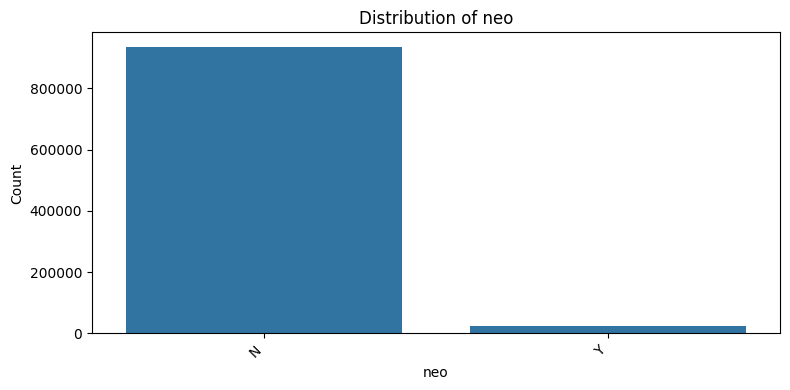

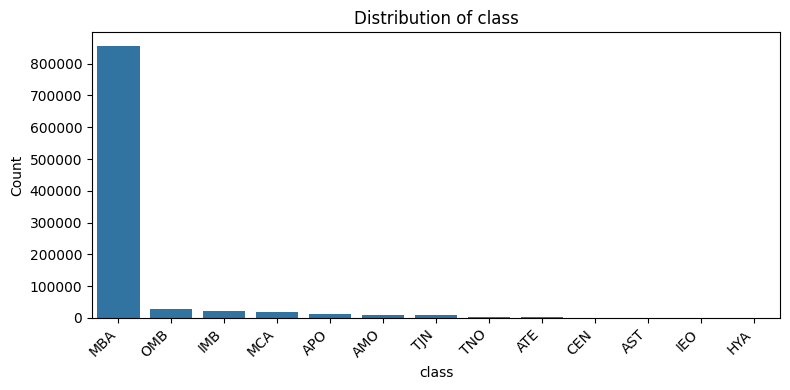

In [207]:
for col in categorical_cols:
    plt.figure(figsize=(8, 4))

    # رسم التكرارات لكل فئة داخل العمود
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)

    plt.title(f"Distribution of {col}", fontsize=12)
    plt.xlabel(col, fontsize=10)
    plt.ylabel("Count", fontsize=10)

    # تعديل زاوية الكتابة على المحور السيني لو كانت الأسماء طويلة أو كثيرة
    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.show()

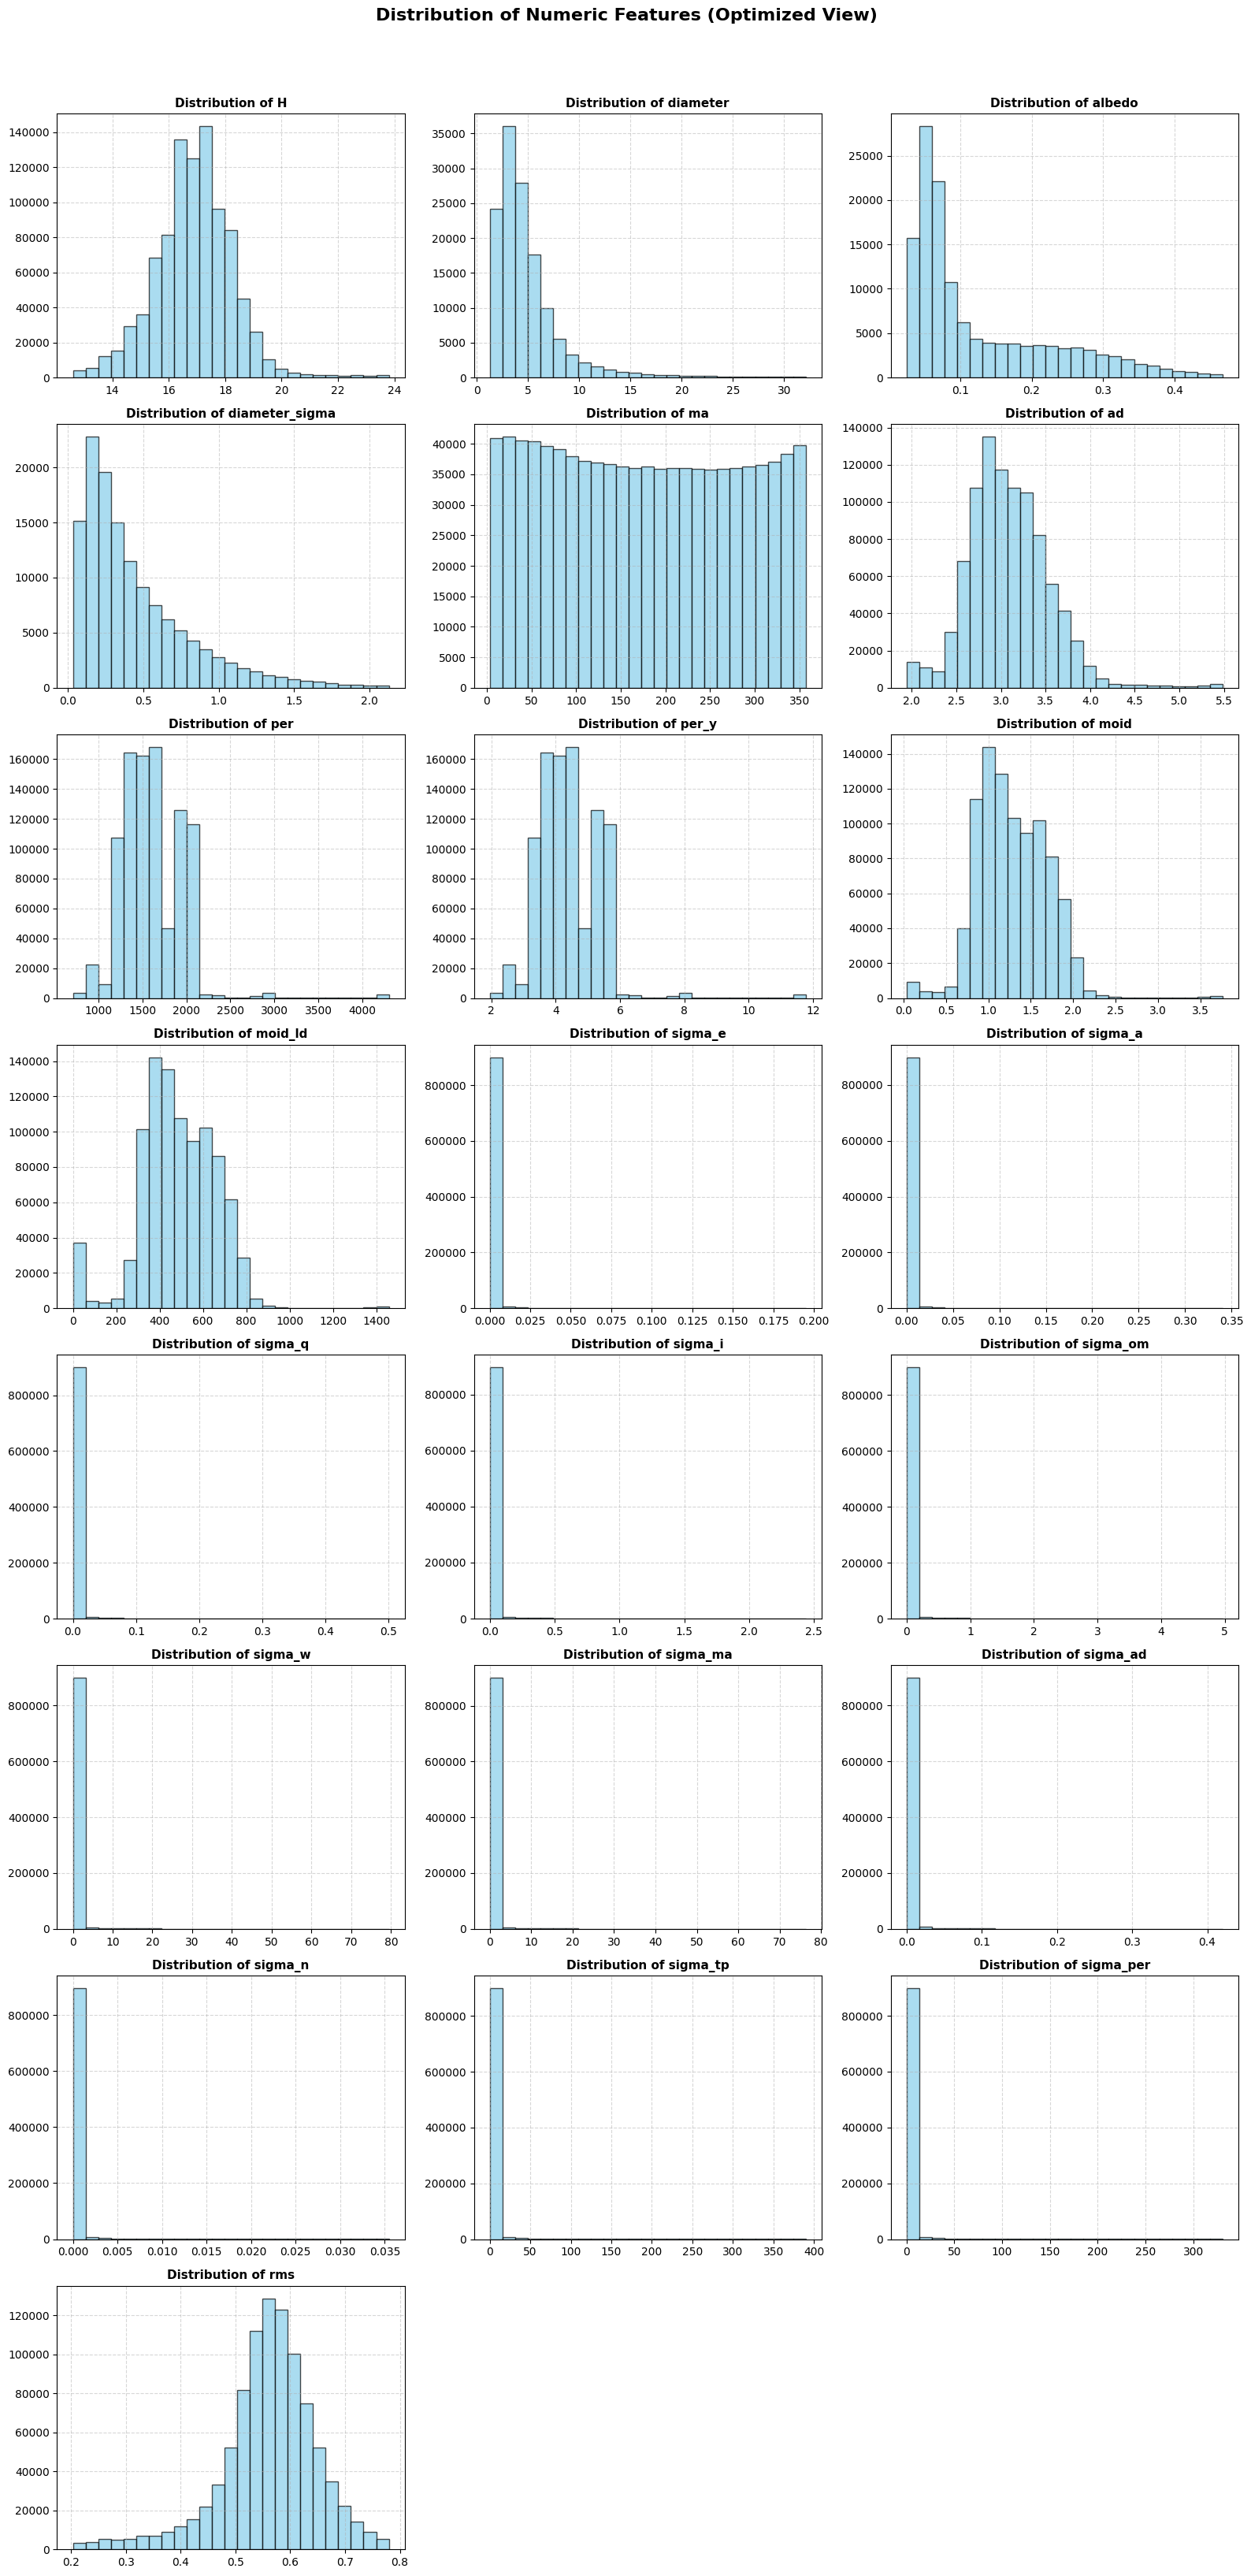

In [208]:
import math
import matplotlib.pyplot as plt

# تحديد الأعمدة الرقمية التي تحتوي على قيم مفقودة
missing_numeric_cols = [col for col in numeric_cols if df[col].isnull().any()]

if missing_numeric_cols:
    num_plots = len(missing_numeric_cols)
    num_cols_per_row = 3  # عرض 3 رسومات في كل صف
    num_rows = math.ceil(num_plots / num_cols_per_row)

    fig_height = max(5, num_rows * 4)
    fig, axes = plt.subplots(num_rows, num_cols_per_row, figsize=(16, fig_height))
    axes = axes.flatten()

    for i, col in enumerate(missing_numeric_cols):
        series = df[col].dropna()

        # استبعاد القيم المتطرفة الشديدة مؤقتاً للرسم فقط (بين النسبة 1% و 99%)
        q_low = series.quantile(0.01)
        q_high = series.quantile(0.99)
        filtered_series = series[(series >= q_low) & (series <= q_high)]

        # رسم الـ Histogram مع ألوان وتنسيق أفضل
        axes[i].hist(filtered_series, bins=25, color='skyblue', edgecolor='black', alpha=0.7)
        axes[i].set_title(f"Distribution of {col}", fontsize=11, fontweight="bold")
        axes[i].grid(True, linestyle='--', alpha=0.5)

    # إخفاء أي محاور فارغة فائضة
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle("Distribution of Numeric Features (Optimized View)", fontsize=16, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No numeric columns with missing values found to plot.")

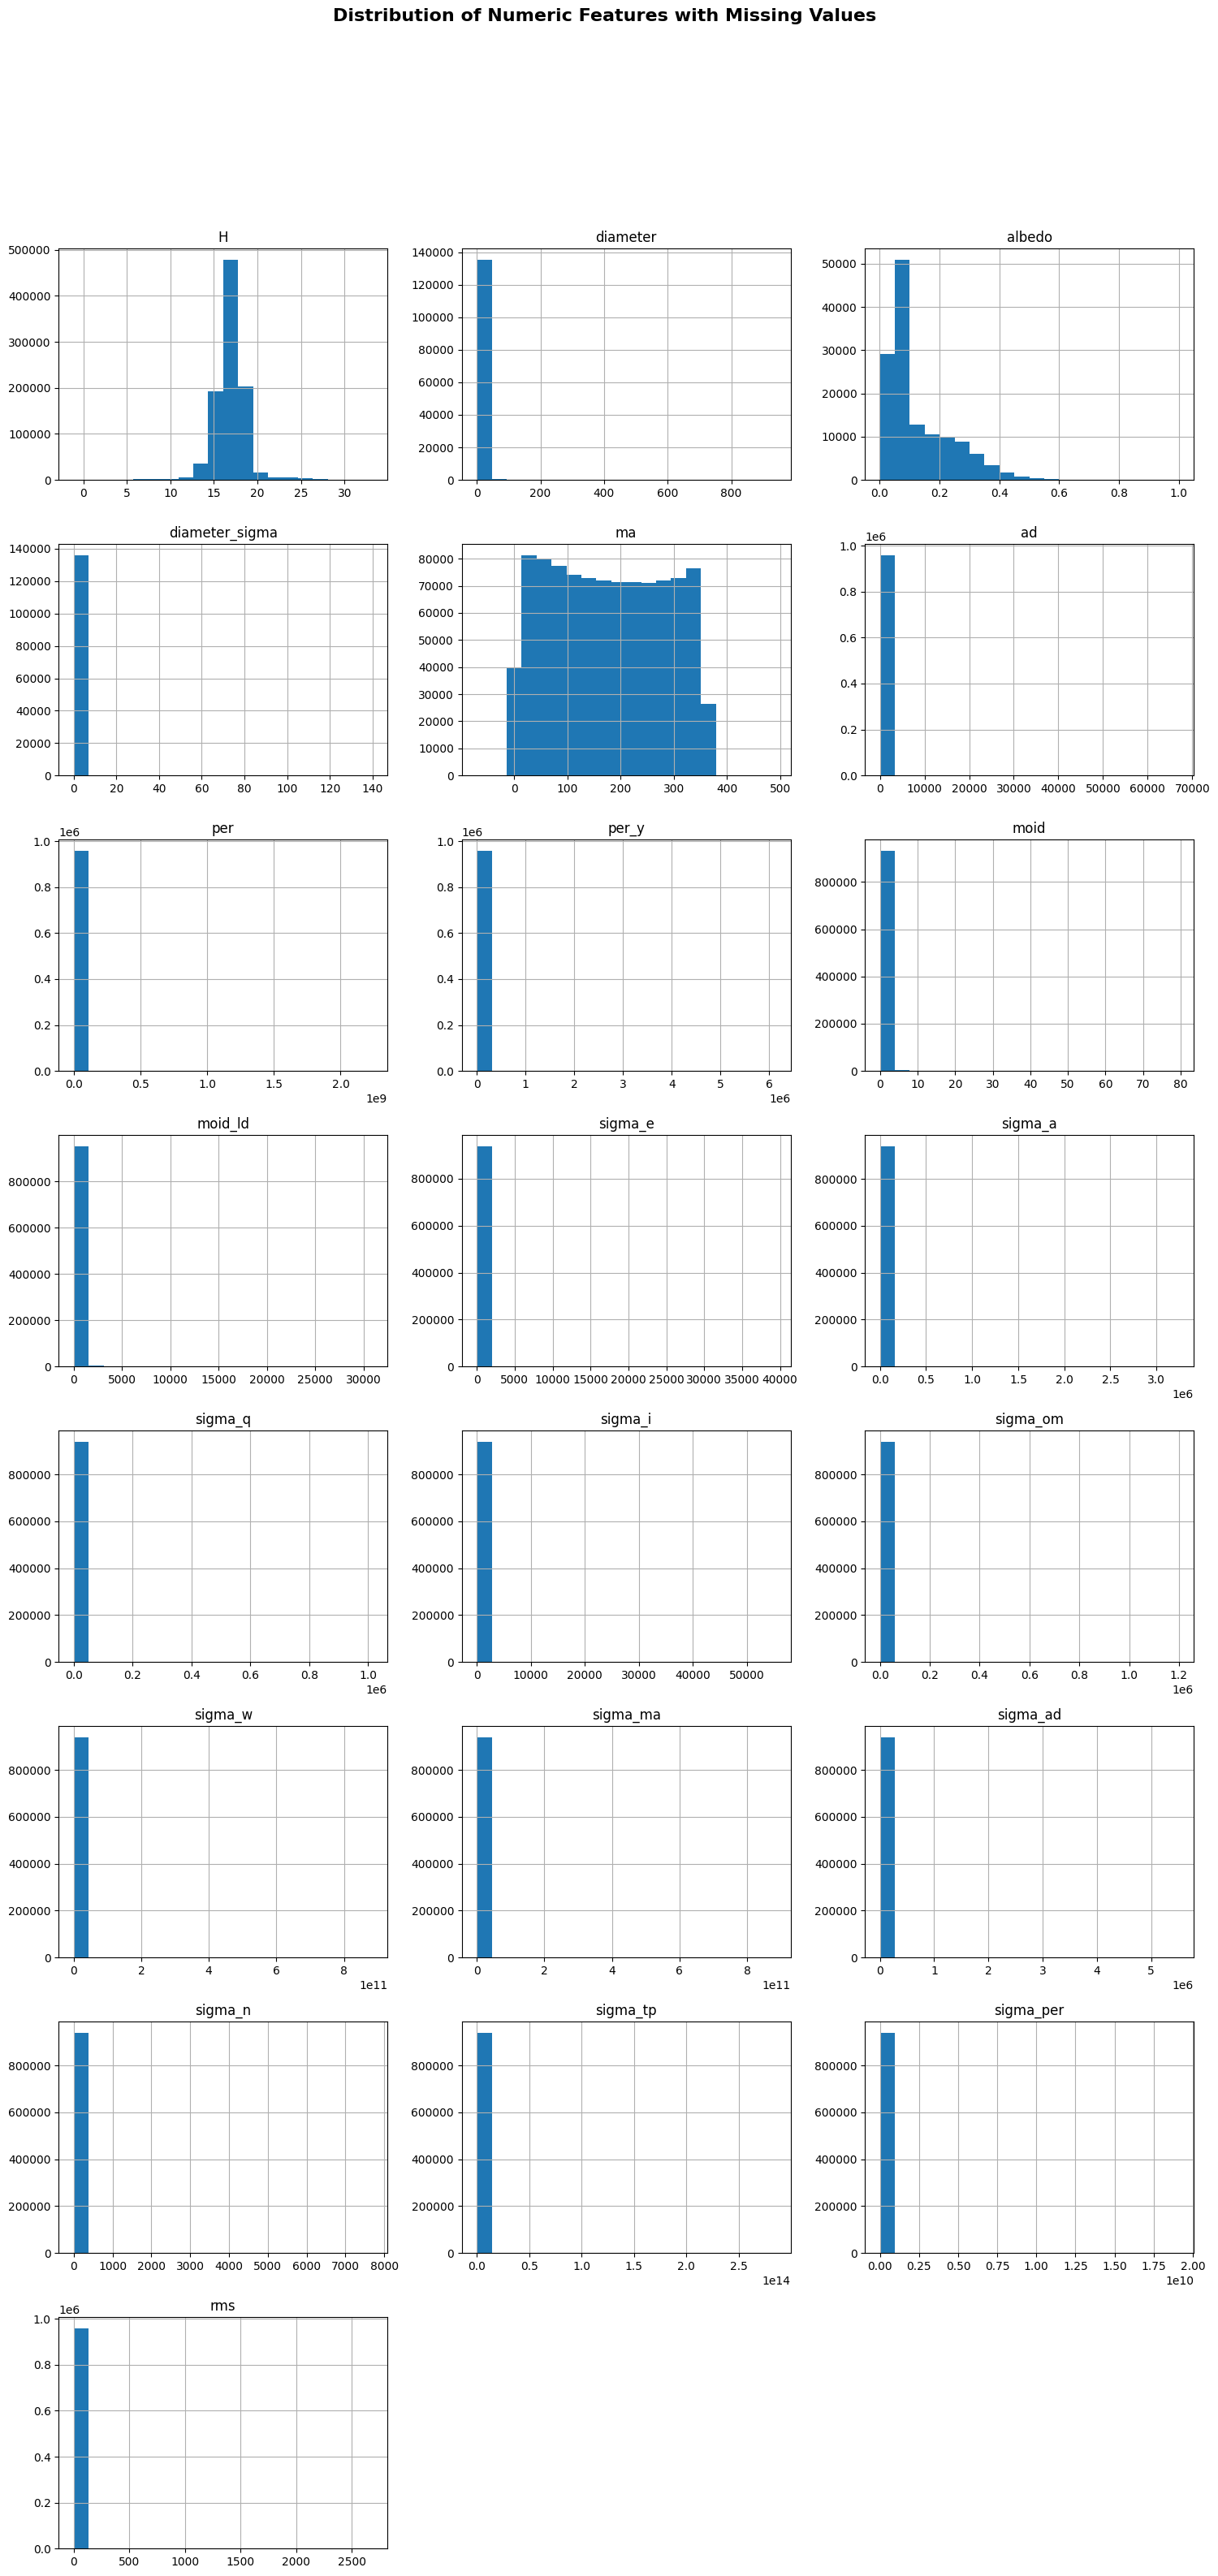

In [209]:
import math

# Identify numeric columns with missing values
missing_numeric_cols = [col for col in numeric_cols if df[col].isnull().any()]

if missing_numeric_cols:
    num_plots = len(missing_numeric_cols)
    num_cols_per_row = 3  # Display up to 3 plots per row
    num_rows = math.ceil(num_plots / num_cols_per_row)

    fig_height = max(5, num_rows * 4) # Adjust height based on number of rows, with a minimum height

    # Plot histograms for numeric columns with missing values
    df[missing_numeric_cols].hist(bins=20, figsize=(15, fig_height), layout=(num_rows, num_cols_per_row))
    plt.suptitle("Distribution of Numeric Features with Missing Values", fontsize=16, fontweight="bold", y=1.02)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust rect to prevent suptitle from overlapping
    plt.show()
else:
    print("No numeric columns with missing values found to plot.")

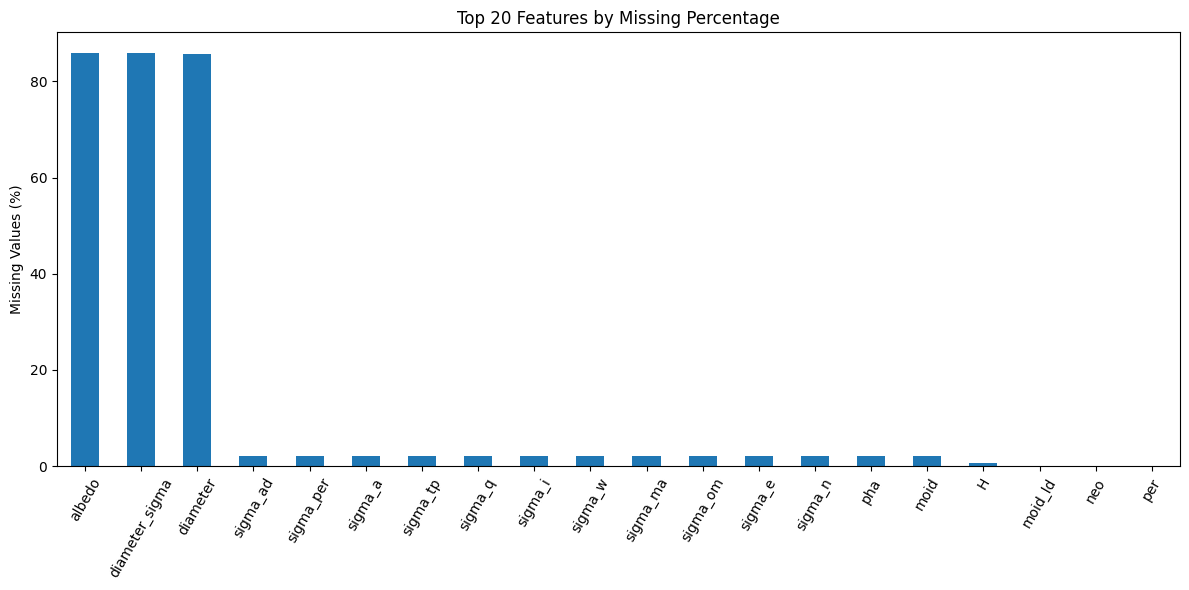

In [210]:
missing_pct = (
    df.isna().mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_pct = missing_pct[
    missing_pct > 0
]

plt.figure(figsize=(12, 6))

missing_pct.head(20).plot(kind="bar")

plt.title("Top 20 Features by Missing Percentage")
plt.ylabel("Missing Values (%)")
plt.xticks(rotation=60)

plt.tight_layout()
plt.show()

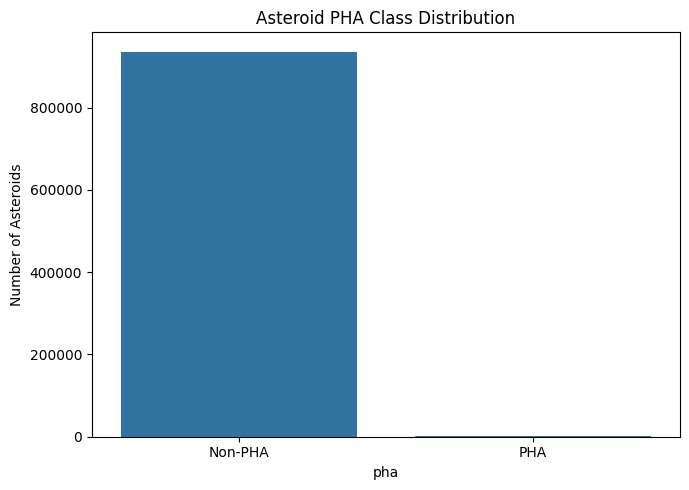

In [211]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=target_counts.index,
    y=target_counts.values
)

# Map 'N' to 'Non-PHA' and 'Y' to 'PHA'
labels = ["Non-PHA" if x == 'N' else "PHA" for x in target_counts.index]
plt.xticks(ticks=range(len(target_counts.index)), labels=labels)
plt.title("Asteroid PHA Class Distribution")
plt.ylabel("Number of Asteroids")

plt.tight_layout()
plt.show()

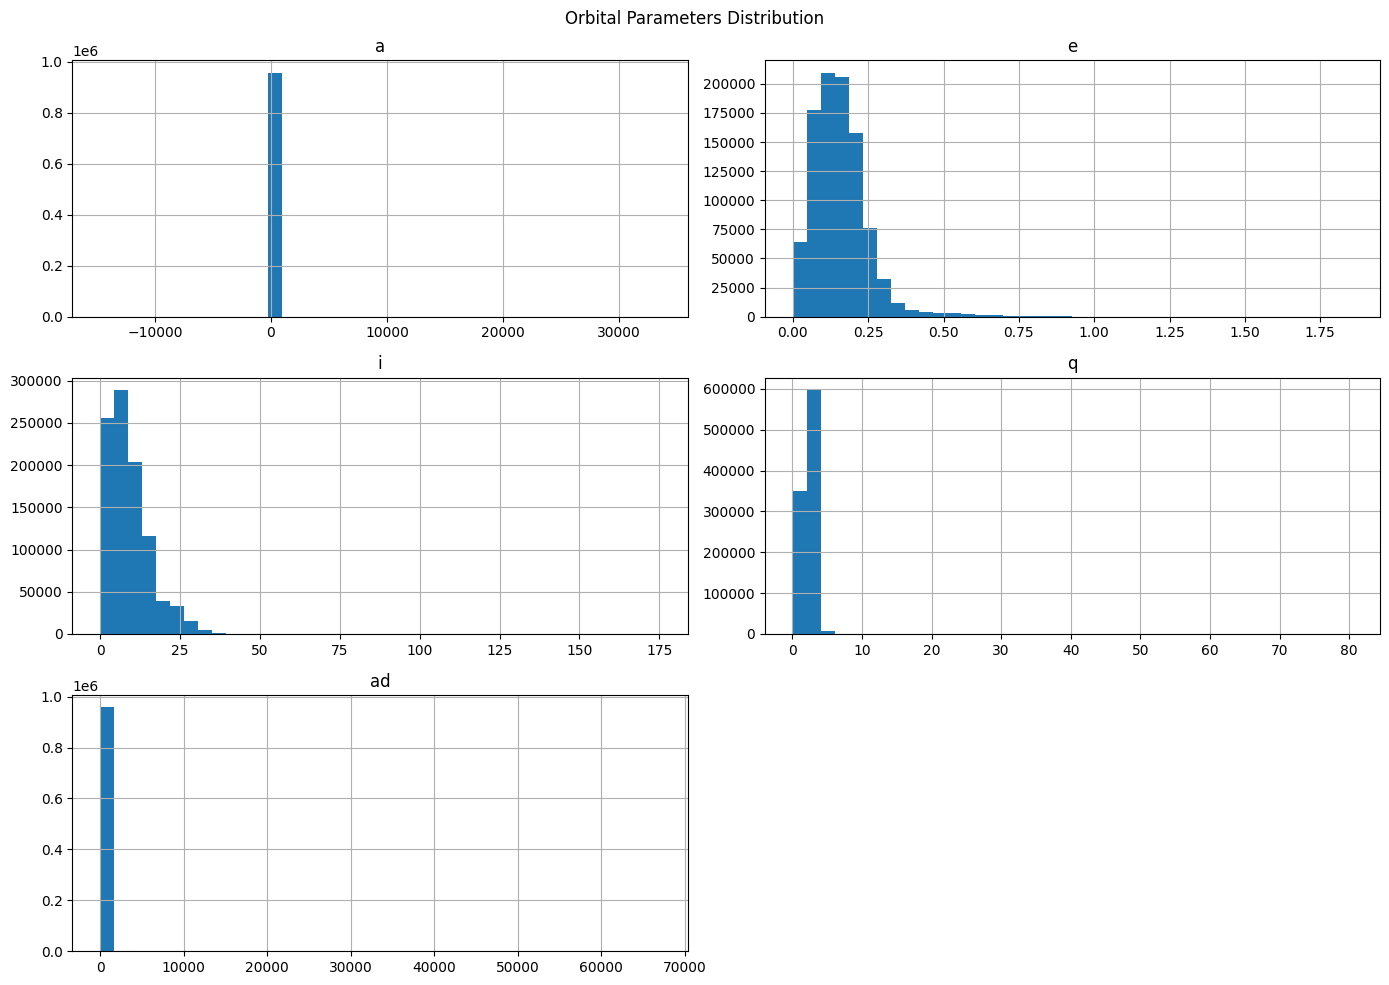

In [212]:
orbital_features = [
    "a", "e", "i", "q", "ad"
]

df[orbital_features].hist(
    figsize=(14, 10),
    bins=40
)

plt.suptitle("Orbital Parameters Distribution")

plt.tight_layout()
plt.show()

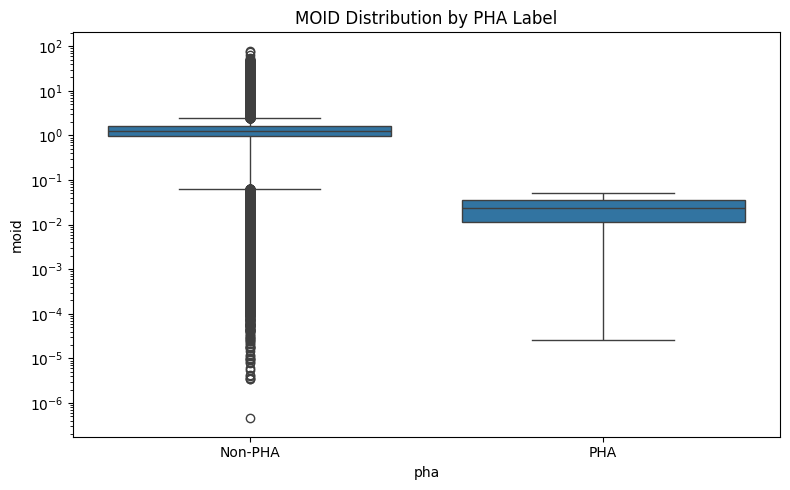

In [213]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="pha",
    y="moid"
)

plt.yscale("log")

plt.title("MOID Distribution by PHA Label")
plt.xticks([0, 1], ["Non-PHA", "PHA"])

plt.tight_layout()
plt.show()

In [214]:
'''
for col in numeric_cols:

    plt.figure(figsize=(10, 3))

    sns.boxplot(
        x=df[col]
    )

    plt.title(f"Boxplot - {col}")
    plt.tight_layout()
    plt.show()'''

'\nfor col in numeric_cols:\n\n    plt.figure(figsize=(10, 3))\n\n    sns.boxplot(\n        x=df[col]\n    )\n\n    plt.title(f"Boxplot - {col}")\n    plt.tight_layout()\n    plt.show()'

CORRELATIONS


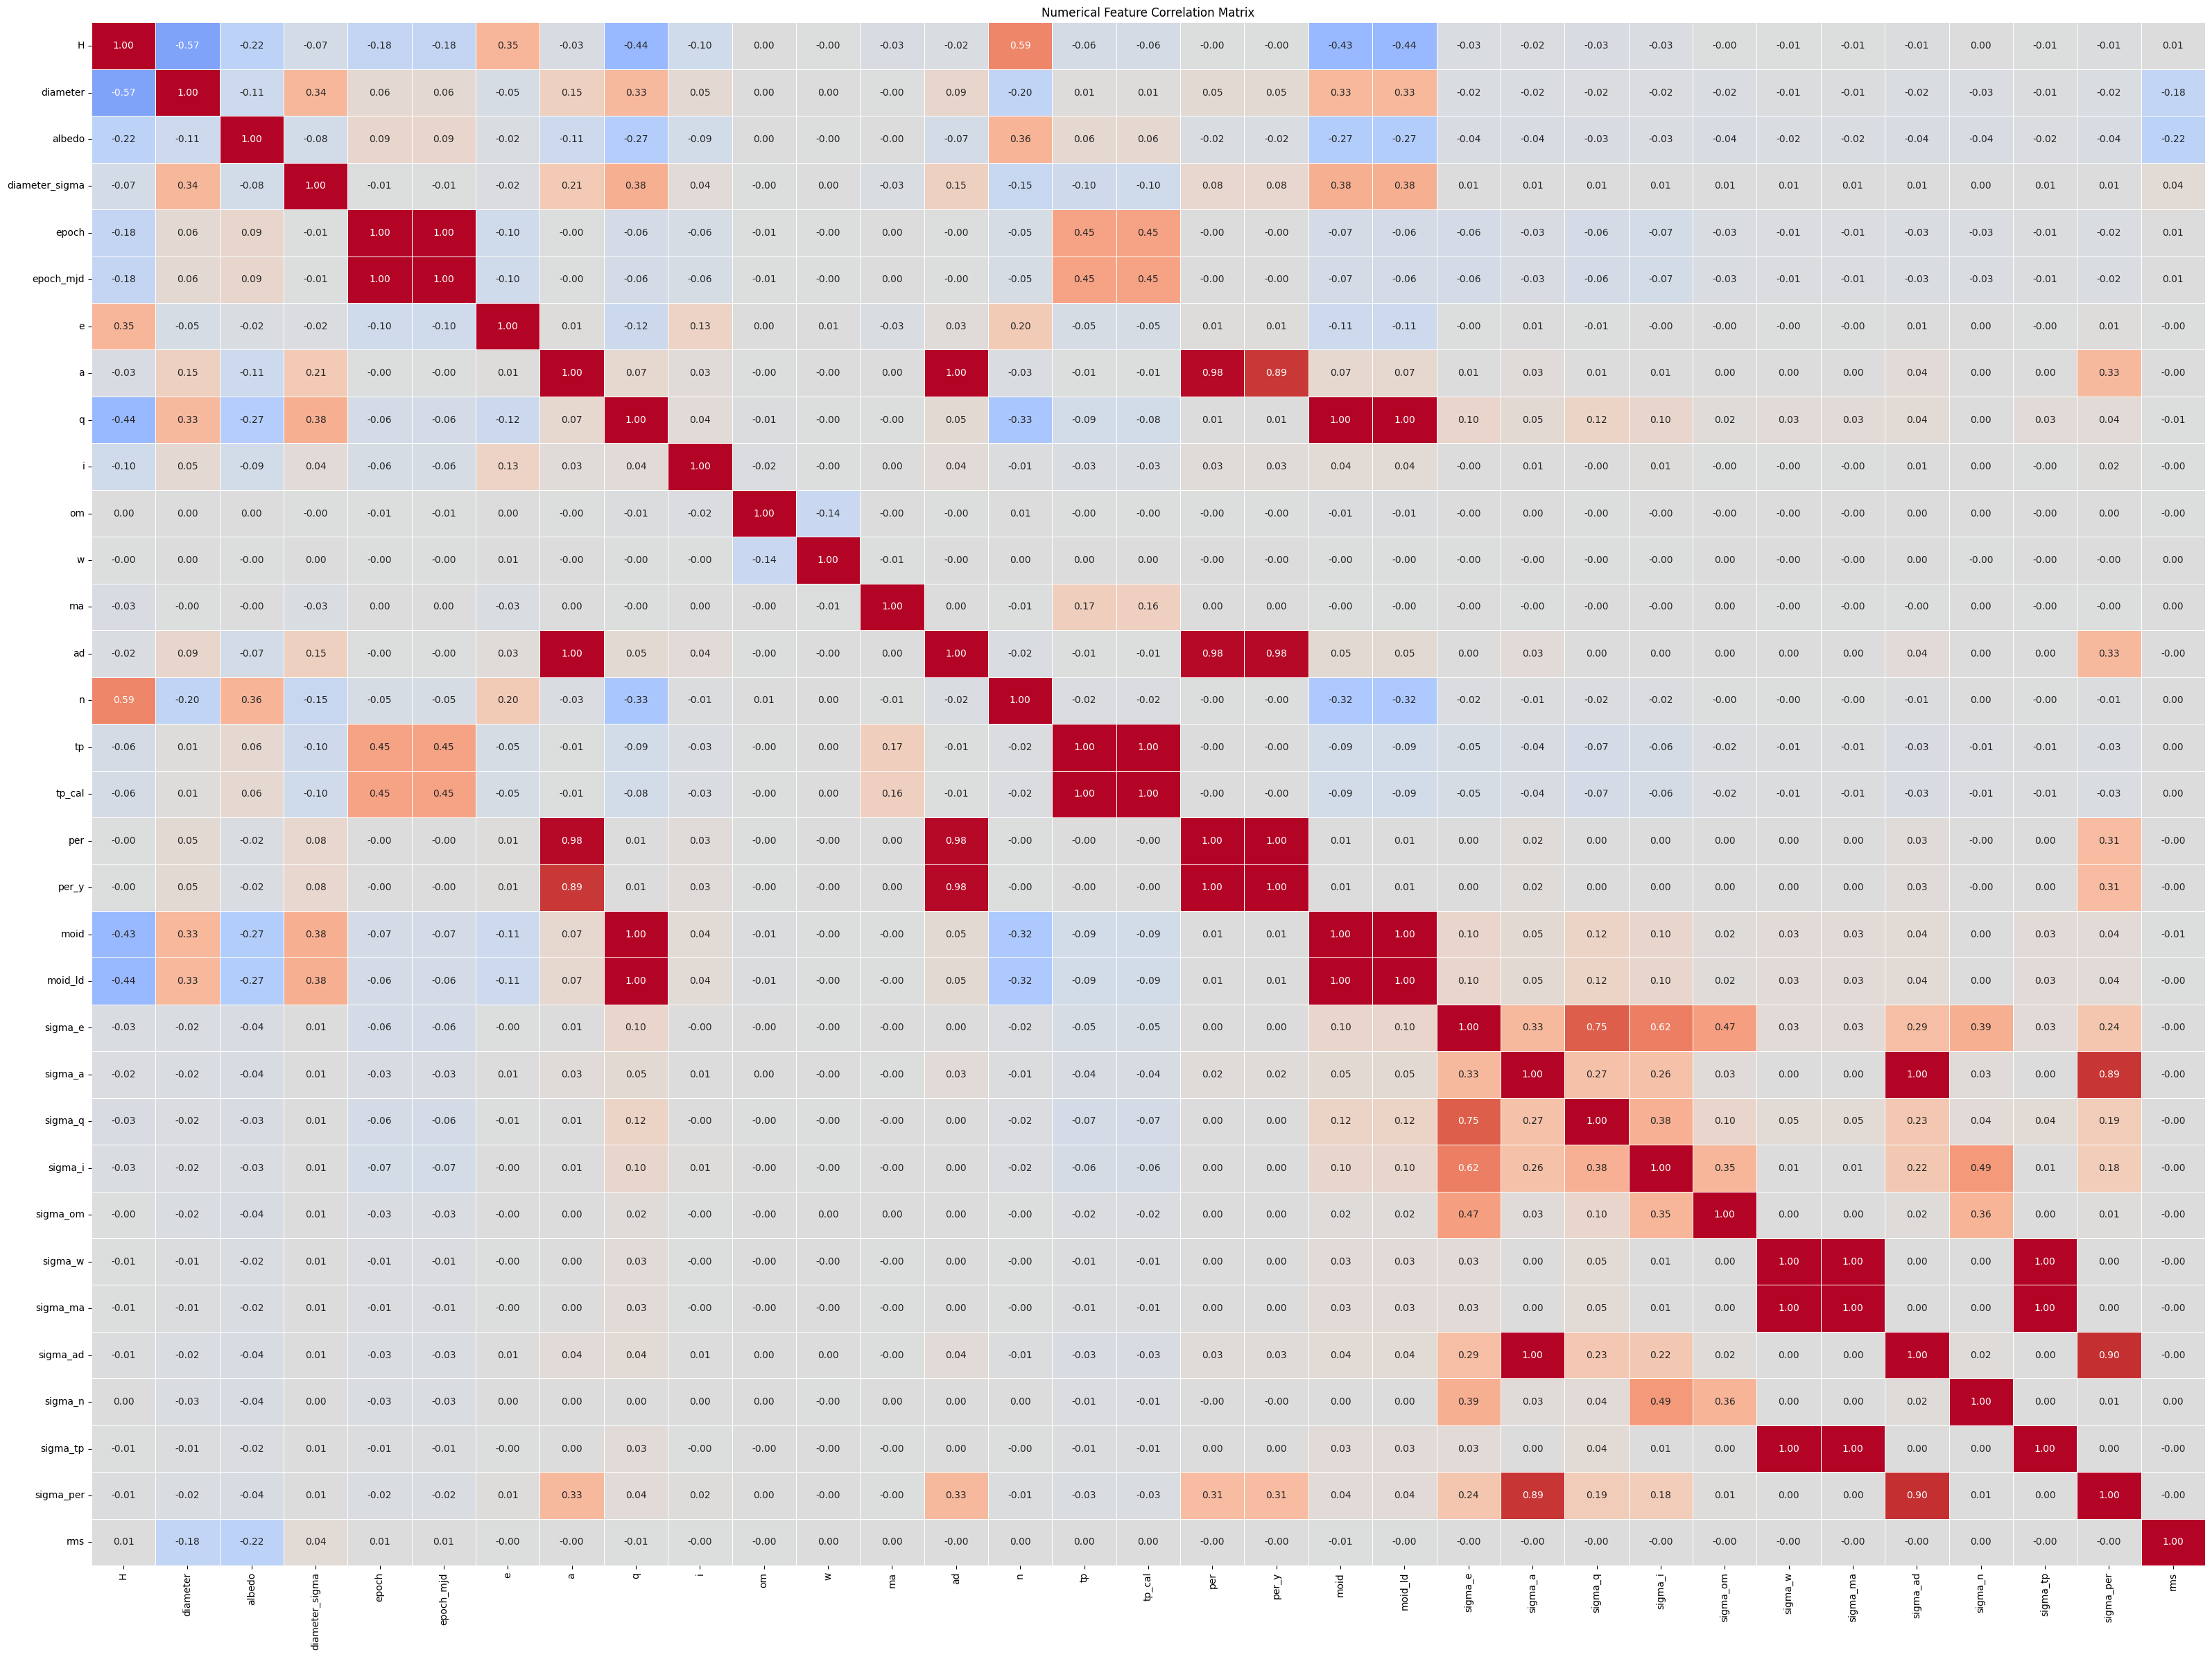

In [215]:
print("CORRELATIONS")

correlation_matrix = df[numeric_cols].corr(
    method="pearson"
)

plt.figure(figsize=(16*2, 12*2))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.4,
    annot=True,
    fmt=".2f",
    cbar=False
)

plt.title("Numerical Feature Correlation Matrix")

plt.tight_layout()
plt.show()

# preprossing

In [216]:
print("\nScientific validity checks:")

validity_checks = {}

# Diameter should not be negative
if "diameter" in df.columns:
    validity_checks["diameter < 0"] = (
        df["diameter"] < 0
    ).sum()

# Albedo normally should be >= 0
if "albedo" in df.columns:
    validity_checks["albedo < 0"] = (
        df["albedo"] < 0
    ).sum()

# Eccentricity should normally be >= 0
if "e" in df.columns:
    validity_checks["e < 0"] = (
        df["e"] < 0
    ).sum()

# Inclination should normally be >= 0
if "i" in df.columns:
    validity_checks["i < 0"] = (
        df["i"] < 0
    ).sum()

# Semi-major axis should normally be positive
if "a" in df.columns:
    validity_checks["a <= 0"] = (
        df["a"] <= 0
    ).sum()

# Perihelion distance should be positive
if "q" in df.columns:
    validity_checks["q <= 0"] = (
        df["q"] <= 0
    ).sum()

display(
    pd.DataFrame(
        validity_checks.items(),
        columns=["Check", "Invalid Count"]
    )
)


Scientific validity checks:


,Check,Invalid Count
0,diameter < 0,0
1,albedo < 0,0
2,e < 0,0
3,i < 0,0
4,a <= 0,4
5,q <= 0,0


# cleaing

In [217]:
df_clean = df.copy()

In [218]:
small_missing_cols = [
   'moid', 'moid_ld', 'sigma_e', 'sigma_a', 'sigma_q',
    'sigma_i', 'sigma_om', 'sigma_w', 'sigma_ma', 'sigma_ad',
    'sigma_n', 'sigma_tp', 'sigma_per', 'rms','per','per_y','ma','ad'
]

# تعويض القيم المفقودة باستخدام الوسيط (Median) لكل عمود
for col in small_missing_cols:
    if col in df_clean.columns:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)

In [219]:
if 'H' in df_clean.columns:
    # حساب المتوسط لعمود H
    mean_h = df_clean['H'].mean()

    # تعويض القيم المفقودة (NaN) بقيمة المتوسط
    df_clean['H'].fillna(mean_h, inplace=True)

In [220]:
import numpy as np

# عدادات لتسجيل عدد القيم التي تم ايجادها
d_imputed_count = 0
p_imputed_count = 0

# التأكد من وجود الأعمدة الأساسية في الداتا
required_cols = ['diameter', 'albedo', 'H']
if all(col in df_clean.columns for col in required_cols):

    # 1. إذا كان القطر (diameter) مفقوداً والانعكاسية (albedo) موجودة و H موجود
    mask_calc_d = df_clean['diameter'].isnull() & df_clean['albedo'].notnull() & df_clean['H'].notnull()

    if mask_calc_d.sum() > 0:
        # حساب القطر باستخدام المعادلة الفلكية
        calc_d = (1329 / np.sqrt(df_clean.loc[mask_calc_d, 'albedo'])) * (10 ** (-0.2 * df_clean.loc[mask_calc_d, 'H']))
        df_clean.loc[mask_calc_d, 'diameter'] = calc_d
        d_imputed_count = mask_calc_d.sum()

    # 2. إذا كانت الانعكاسية (albedo) مفقودة والقطر (diameter) موجود و H موجود
    mask_calc_p = df_clean['albedo'].isnull() & df_clean['diameter'].notnull() & df_clean['H'].notnull()

    if mask_calc_p.sum() > 0:
        # حساب الانعكاسية بالمعادلة العكسية
        calc_p = ((1329 / df_clean.loc[mask_calc_p, 'diameter']) ** 2) * (10 ** (-0.4 * df_clean.loc[mask_calc_p, 'H']))
        df_clean.loc[mask_calc_p, 'albedo'] = calc_p
        p_imputed_count = mask_calc_p.sum()

    # (الحالة الثالثة: إذا كان الاثنان مفقودين، يتم تخطيهما تلقائياً لعدم تطابق الشروط)

    # طباعة التقرير النهائي بالعدادات
    print("=" * 40)
    print(" تقرير استنتاج القيم الرياضية والفلكية:")
    print("=" * 40)
    print(f"- عدد قيم القطر (diameter) التي تم ايجادها: {d_imputed_count}")
    print(f"- عدد قيم الانعكاسية (albedo) التي تم ايجادها: {p_imputed_count}")
    print(f"- **الإجمالي الكلي للقيم التي تم حسابها:** {d_imputed_count + p_imputed_count}")
    print("=" * 40)

else:
    print("تنبيه: بعض الأعمدة المطلوبة (diameter, albedo, H) غير موجودة في جدول البيانات.")

 تقرير استنتاج القيم الرياضية والفلكية:
- عدد قيم القطر (diameter) التي تم ايجادها: 3
- عدد قيم الانعكاسية (albedo) التي تم ايجادها: 1109
- **الإجمالي الكلي للقيم التي تم حسابها:** 1112


In [221]:
# لمعرفة عدد القيم المفقودة في كل عمود على حدة (مرتبة تنازلياً)
missing_counts = df_clean.isnull().sum().sort_values(ascending=False)
print("عدد القيم المفقودة في كل عمود:")
print(missing_counts)

# لمعرفة إجمالي عدد القيم المفقودة في جدول البيانات بالكامل
total_missing = df_clean.isnull().sum().sum()
print(f"\nإجمالي القيم المفقودة في الداتا بالكامل: {total_missing}")

عدد القيم المفقودة في كل عمود:
diameter_sigma    822443
diameter          822312
albedo            822312
pha                19921
neo                    4
H                      0
epoch                  0
epoch_mjd              0
e                      0
a                      0
q                      0
i                      0
om                     0
w                      0
ma                     0
ad                     0
n                      0
tp                     0
tp_cal                 0
per                    0
per_y                  0
moid                   0
moid_ld                0
sigma_e                0
sigma_a                0
sigma_q                0
sigma_i                0
sigma_om               0
sigma_w                0
sigma_ma               0
sigma_ad               0
sigma_n                0
sigma_tp               0
sigma_per              0
class                  0
rms                    0
dtype: int64

إجمالي القيم المفقودة في الداتا بالكامل: 2486992


geting dia

In [222]:
df_dia=df_clean.drop(['epoch',
           'epoch_mjd','i', 'om', 'w','ma','tp', 'tp_cal', 'per', 'per_y','sigma_e', 'sigma_a',
           'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w','sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per'],axis=1)

In [223]:
print(f" Shape after droping unnessesary columns : {df_dia.shape}")

 Shape after droping unnessesary columns : (958524, 15)


In [224]:
df_dia=df_dia.dropna(subset=["diameter"])
print(f"Shape after droping the target nulls :{df_dia.shape}")

Shape after droping the target nulls :(136212, 15)


In [225]:
#null percentage in each column

print("Missing value percentage in each column after dropping the diameter nulls :")
(df_dia.isna().sum()/len(df)*100).sort_values(ascending=False)

Missing value percentage in each column after dropping the diameter nulls :


,0
diameter_sigma,0.013667
pha,0.000000
neo,0.000000
H,0.000000
diameter,0.000000
albedo,0.000000
e,0.000000
a,0.000000
q,0.000000
ad,0.000000


Text(0.5, 0.98, 'Distribution of Features with Missing Values')

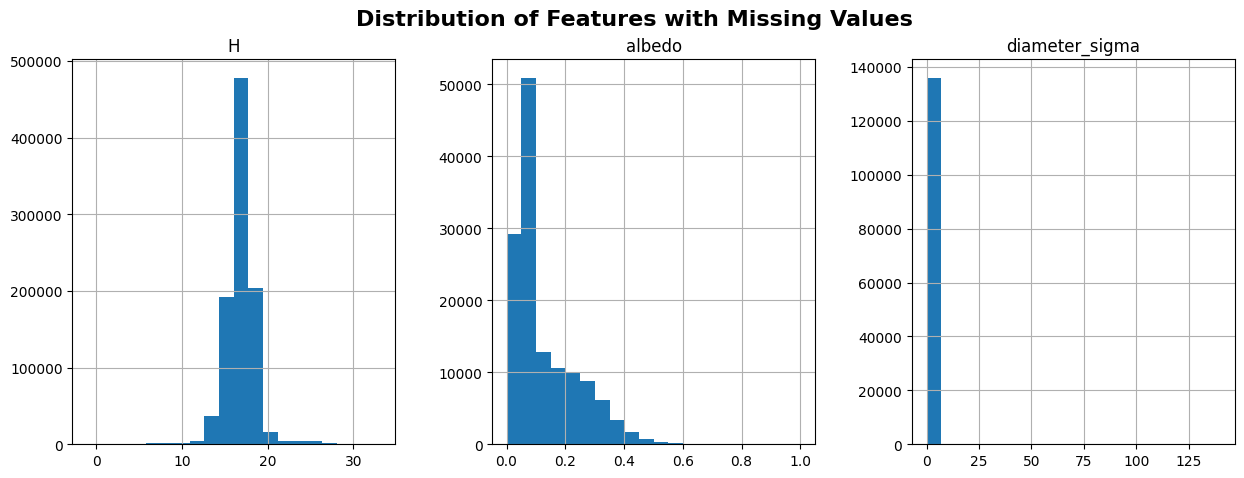

In [226]:
cols=['H','albedo','diameter_sigma']
df[cols].hist(bins=20, figsize=(15, 5), layout=(1,3))
plt.suptitle("Distribution of Features with Missing Values",fontsize=16,fontweight="bold")

In [227]:
df_dia['diameter_sigma'] = df_dia['diameter_sigma'].fillna(df_dia['diameter_sigma'].median())


In [228]:
print(f"The number of missing values : ")
print(df_dia.isna().sum())

The number of missing values : 
neo               0
pha               0
H                 0
diameter          0
albedo            0
diameter_sigma    0
e                 0
a                 0
q                 0
ad                0
n                 0
moid              0
moid_ld           0
class             0
rms               0
dtype: int64


outliers

In [229]:
def outlier_report (cols):
    outlier_data = []
    for col in cols:
        Q1 = df_dia[col].quantile(0.25)
        Q3 = df_dia[col].quantile(0.75)
        IQR=Q3-Q1
        lower_bound = Q1-1.5*IQR
        upper_bound = Q3+1.5*IQR

        outlier_count = ((df_dia[col]<lower_bound)|(df_dia[col]>upper_bound)).sum()
        outlier_per = (outlier_count/len(df_dia))*100
        outlier_data.append([col,outlier_count,outlier_per])

    outlier_df_dia = pd.DataFrame(outlier_data,columns=['Column','Outliers Count','Outliers %'])
    outlier_df_dia = outlier_df_dia.sort_values(by ='Outliers Count',ascending=False)
    print(outlier_df_dia.to_string(index=False))


In [230]:
num_cols=df_dia.select_dtypes('number')
outlier_report(num_cols)

        Column  Outliers Count  Outliers %
      diameter            9613    7.057381
diameter_sigma            6878    5.049482
           rms            4956    3.638446
        albedo            3660    2.686988
            ad            3570    2.620914
             a            3426    2.515197
             n            3256    2.390391
             H            3223    2.366165
             q            2710    1.989546
          moid            2555    1.875753
       moid_ld            2555    1.875753
             e            1504    1.104161


In [231]:
Q1 = df_dia['diameter'].quantile(0.25)
Q3 = df_dia['diameter'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1-1.5*IQR
upper_bound = Q3+1.5*IQR
df_dia = df_dia[(df_dia['diameter']>lower_bound)&(df_dia['diameter']<upper_bound)]

print(f" Shape after droping the diameter column outliers : {df_dia.shape}")

 Shape after droping the diameter column outliers : (126599, 15)


In [232]:
for col in num_cols:
    Q1 = df_dia[col].quantile(0.25)
    Q3 = df_dia[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1-1.5*IQR
    upper_bound = Q3+1.5*IQR
    df_dia[col] = np.where(df_dia[col] < lower_bound, lower_bound, np.where(df_dia[col] > upper_bound, upper_bound, df_dia[col]))

In [233]:
outlier_report(num_cols)

        Column  Outliers Count  Outliers %
             H               0         0.0
      diameter               0         0.0
        albedo               0         0.0
diameter_sigma               0         0.0
             e               0         0.0
             a               0         0.0
             q               0         0.0
            ad               0         0.0
             n               0         0.0
          moid               0         0.0
       moid_ld               0         0.0
           rms               0         0.0


In [234]:
obj_cols = df_dia.select_dtypes(include=['object']).columns.tolist()
for col in obj_cols:
    print (df_dia[col].value_counts())

neo
N    125751
Y       848
Name: count, dtype: int64
pha
N    126375
Y       224
Name: count, dtype: int64
class
MBA    118480
OMB      6211
IMB       564
APO       488
MCA       350
AMO       264
TJN       129
ATE        96
CEN        12
AST         3
TNO         2
Name: count, dtype: int64


Text(0.5, 1.0, 'Countplot of class')

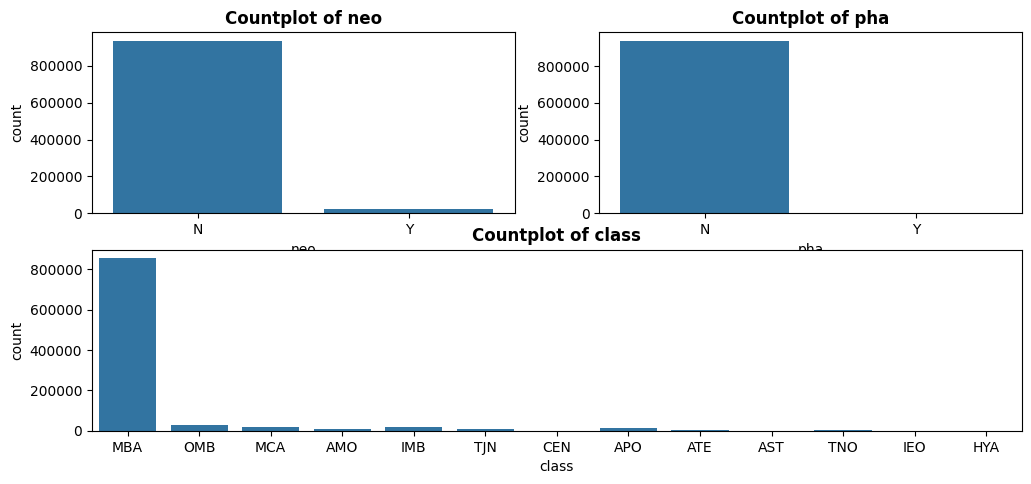

In [235]:
fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(3, 2) # Changed from 2,2 to 3,2 to allow a third row

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

ax3 = fig.add_subplot(gs[1, :])

sns.countplot(x=df[obj_cols[0]], ax=ax1)
ax1.set_title(f"Countplot of {obj_cols[0]}", fontweight="bold", fontsize=12)

sns.countplot(x=df[obj_cols[1]], ax=ax2)
ax2.set_title(f"Countplot of {obj_cols[1]}", fontweight="bold", fontsize=12)

sns.countplot(x=df[obj_cols[2]], ax=ax3)
ax3.set_title(f"Countplot of {obj_cols[2]}", fontweight="bold", fontsize=12)



In [236]:
features = num_cols.columns.to_list()
row = 4
cols_per_row=3
plt.figure(figsize=(20,10))

for i,feature in enumerate(features,start=1):
    plt.subplot(row , cols_per_row,i)
    sns.scatterplot(x=feature,y=df_dia['diameter'],data=df_dia)
    plt.title(f"{feature} vs diameter" )
    plt.tight_layout()

plt.suptitle("Features vs Target ", fontsize=16 ,fontweight ="bold" ,y=1.05)


Text(0.5, 1.05, 'Features vs Target ')

Error in callback <function flush_figures at 0x795f7a0ccae0> (for post_execute):


KeyboardInterrupt: 

In [237]:
x_dia = df_dia.drop('diameter', axis=1, errors='ignore')
y_dia = df_dia['diameter']

In [238]:
xtrn_dia, xtst_dia, ytrn_dia, ytst_dia = train_test_split(
    x_dia,y_dia,
    test_size=0.2,
    random_state=42
)

In [239]:
"""for col in obj_cols:
    if col in xtrn_dia.columns:
        le = LabelEncoder()
        xtrn_dia[col] = le.fit_transform(xtrn_dia[col])
        xtst_dia[col] = le.transform(xtst_dia[col])"""

'for col in obj_cols:\n    if col in xtrn_dia.columns:\n        le = LabelEncoder()\n        xtrn_dia[col] = le.fit_transform(xtrn_dia[col])\n        xtst_dia[col] = le.transform(xtst_dia[col])'

In [240]:
from sklearn.preprocessing import OneHotEncoder

# categorical columns except pha
onehot_cols = [col for col in obj_cols if col != 'pha']

encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

# Fit على train فقط
X_train_encoded = encoder.fit_transform(xtrn_dia[onehot_cols])

# Transform test
X_test_encoded = encoder.transform(xtst_dia[onehot_cols])

# أسماء الأعمدة الجديدة
encoded_cols = encoder.get_feature_names_out(onehot_cols)

# نحولهم DataFrame
X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=encoded_cols,
    index=xtrn_dia.index
)

X_test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=encoded_cols,
    index=xtst_dia.index
)

# نشيل الـ categorical columns القديمة
xtrn_dia = xtrn_dia.drop(columns=onehot_cols)
xtst_dia = xtst_dia.drop(columns=onehot_cols)

# نضيف الـ One-Hot columns
xtrn_dia = pd.concat([xtrn_dia, X_train_encoded], axis=1)
xtst_dia = pd.concat([xtst_dia, X_test_encoded], axis=1)

In [241]:
print("Number of original categorical columns:", len(onehot_cols))
print("Number of new encoded columns:", len(encoded_cols))

print("\nEncoded data:")
display(xtrn_dia[encoded_cols].head())

Number of original categorical columns: 2
Number of new encoded columns: 13

Encoded data:


,neo_N,neo_Y,class_AMO,class_APO,class_AST,class_ATE,class_CEN,class_IMB,class_MBA,class_MCA,class_OMB,class_TJN,class_TNO
17881,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
59167,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
680647,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
163160,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
274453,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [242]:

xtrn_dia['pha'] = df_clean['pha'].map({
    'N': 0,
    'Y': 1
})
xtst_dia['pha'] = df_clean['pha'].map({
    'N': 0,
    'Y': 1
})

counts = xtrn_dia['pha'].value_counts()
print(counts)

pha
0.0    101100
1.0       179
Name: count, dtype: int64


In [243]:
display(xtrn_dia.head(2))

,pha,H,albedo,diameter_sigma,e,a,q,ad,n,moid,moid_ld,rms,neo_N,neo_Y,class_AMO,class_APO,class_AST,class_ATE,class_CEN,class_IMB,class_MBA,class_MCA,class_OMB,class_TJN,class_TNO
17881,0.0,14.7,0.187,0.155,0.077147,2.278495,2.102716,2.454275,0.286571,1.096150,426.588695,0.54125,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
59167,0.0,15.6,0.286,0.201,0.157349,2.325275,1.959395,2.691154,0.277967,0.976294,379.944336,0.49331,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [244]:
display(xtst_dia.head(2))

,pha,H,albedo,diameter_sigma,e,a,q,ad,n,moid,moid_ld,rms,neo_N,neo_Y,class_AMO,class_APO,class_AST,class_ATE,class_CEN,class_IMB,class_MBA,class_MCA,class_OMB,class_TJN,class_TNO
165102,0.0,15.3,0.053,0.180,0.043091,2.928838,2.802631,3.055045,0.196635,1.795280,698.669118,0.60680,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
281821,0.0,16.9,0.066,0.035,0.308646,2.686078,1.857030,3.515125,0.223886,0.873693,340.015105,0.52917,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [245]:
scaler = StandardScaler()
xtrn_dia_s = scaler.fit_transform(xtrn_dia)
xtst_dia_s = scaler.transform(xtst_dia)

In [246]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

print(f"XGBOOST")
xgb_dia_model = xgb.XGBRegressor(n_estimators=100, random_state=42)
xgb_dia_model.fit(xtrn_dia, ytrn_dia)
xgb_dia_pred = xgb_dia_model.predict(xtst_dia)

xgb_dia_r2 = r2_score(ytst_dia, xgb_dia_pred)
xgb_dia_rmse = np.sqrt(mean_squared_error(ytst_dia, xgb_dia_pred))
print(f"R²: {xgb_dia_r2:.3f}")
print(f"RMSE: {xgb_dia_rmse:.3f}")

XGBOOST
R²: 0.950
RMSE: 0.426


filling df_clean 'dia'

In [247]:
df_clean = df_clean.dropna(subset=['pha', 'neo']).copy()

In [248]:
print(f"The number of missing values : ")
print(df_clean.isna().sum())

The number of missing values : 
neo                    0
pha                    0
H                      0
diameter          802387
albedo            802387
diameter_sigma    802518
epoch                  0
epoch_mjd              0
e                      0
a                      0
q                      0
i                      0
om                     0
w                      0
ma                     0
ad                     0
n                      0
tp                     0
tp_cal                 0
per                    0
per_y                  0
moid                   0
moid_ld                0
sigma_e                0
sigma_a                0
sigma_q                0
sigma_i                0
sigma_om               0
sigma_w                0
sigma_ma               0
sigma_ad               0
sigma_n                0
sigma_tp               0
sigma_per              0
class                  0
rms                    0
dtype: int64


In [249]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# ============================================================
# 1. تجهيز الـ Features والـ Target
# ============================================================

X_clean = df_clean.drop(columns=['pha'])

y_clean = df_clean['pha'].map({
    'N': 0,
    'Y': 1
})


# ============================================================
# 2. تقسيم البيانات
# ============================================================

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean,
    y_clean,
    test_size=0.2,
    random_state=42,
    stratify=y_clean
)


# ============================================================
# 3. تحديد الأعمدة النصية من TRAIN فقط
# ============================================================

obj_cols = X_train_clean.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print("Categorical columns:")
print(obj_cols)


# ============================================================
# 4. One-Hot Encoding
# ============================================================

encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

# Fit على TRAIN فقط
X_train_encoded = encoder.fit_transform(
    X_train_clean[obj_cols]
)

# Transform TEST باستخدام نفس الـ encoder
X_test_encoded = encoder.transform(
    X_test_clean[obj_cols]
)


# ============================================================
# 5. الحصول على أسماء الأعمدة الجديدة
# ============================================================

encoded_cols = encoder.get_feature_names_out(obj_cols)

X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=encoded_cols,
    index=X_train_clean.index
)

X_test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=encoded_cols,
    index=X_test_clean.index
)


# ============================================================
# 6. حذف الأعمدة النصية الأصلية
# ============================================================

X_train_clean = X_train_clean.drop(columns=obj_cols)
X_test_clean = X_test_clean.drop(columns=obj_cols)


# ============================================================
# 7. دمج الـ One-Hot columns مع باقي الـ numerical columns
# ============================================================

X_train_clean = pd.concat(
    [X_train_clean, X_train_encoded],
    axis=1
)

X_test_clean = pd.concat(
    [X_test_clean, X_test_encoded],
    axis=1
)


# ============================================================
# 8. التأكد من النتيجة
# ============================================================

print("\nEncoding completed successfully!")

print("\nTrain shape:", X_train_clean.shape)
print("Test shape :", X_test_clean.shape)

print("\nRemaining object columns in train:")
print(X_train_clean.select_dtypes(
    include=['object', 'category']
).columns.tolist())

print("\nEncoded columns:")
print(encoded_cols.tolist())

print("\nFirst 5 rows:")
display(X_train_clean.head())

Categorical columns:
['neo', 'class']

Encoding completed successfully!

Train shape: (750879, 47)
Test shape : (187720, 47)

Remaining object columns in train:
[]

Encoded columns:
['neo_N', 'neo_Y', 'class_AMO', 'class_APO', 'class_AST', 'class_ATE', 'class_CEN', 'class_IEO', 'class_IMB', 'class_MBA', 'class_MCA', 'class_OMB', 'class_TJN', 'class_TNO']

First 5 rows:


,H,diameter,albedo,diameter_sigma,epoch,epoch_mjd,e,a,q,i,om,w,ma,ad,n,tp,tp_cal,per,per_y,moid,moid_ld,sigma_e,sigma_a,sigma_q,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,rms,neo_N,neo_Y,class_AMO,class_APO,class_AST,class_ATE,class_CEN,class_IEO,class_IMB,class_MBA,class_MCA,class_OMB,class_TJN,class_TNO
844659,18.9,NaN,NaN,NaN,2459000.5,59000,0.051481,1.938989,1.839169,17.745871,337.106017,215.957694,49.019768,2.038809,0.365041,2.458866e+06,2.020012e+07,986.191943,2.700046,0.857924,333.878283,1.991300e-06,3.929700e-06,7.430900e-06,0.000084,0.000022,0.002478,0.000978,4.132000e-06,1.109700e-06,0.003020,0.002998,0.56955,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
218098,16.1,NaN,NaN,NaN,2459000.5,59000,0.237697,2.307693,1.759162,7.640454,109.405665,227.782286,27.734613,2.856224,0.281149,2.458902e+06,2.020022e+07,1280.458310,3.505704,0.759779,295.683193,5.409700e-08,8.062400e-09,1.259700e-07,0.000004,0.000037,0.000038,0.000008,9.978800e-09,1.473400e-09,0.000029,0.000007,0.54613,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
621933,17.1,NaN,NaN,NaN,2459000.5,59000,0.197822,2.693656,2.160792,9.344051,46.954910,327.600145,315.904899,3.226520,0.222941,2.459198e+06,2.020121e+07,1614.773635,4.421009,1.169180,455.009781,1.045000e-06,1.804900e-07,2.675800e-06,0.000041,0.000046,0.000285,0.000283,2.162000e-07,2.240800e-08,0.001287,0.000162,0.69876,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
246607,16.0,NaN,NaN,NaN,2459000.5,59000,0.226008,2.808858,2.174032,10.551133,107.449753,305.672133,154.790929,3.443684,0.209368,2.458261e+06,2.018052e+07,1719.464291,4.707637,1.205150,469.008225,3.922800e-08,2.221500e-08,1.111200e-07,0.000005,0.000029,0.000032,0.000015,2.723600e-08,2.483800e-09,0.000070,0.000020,0.62354,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
195613,14.9,8.036,0.036,0.908,2459000.5,59000,0.342750,3.074403,2.020651,12.231760,90.184613,225.003200,107.906747,4.128155,0.182837,2.458410e+06,2.018102e+07,1968.972000,5.390752,1.026900,399.638673,6.161100e-08,3.086200e-08,1.795400e-07,0.000006,0.000037,0.000038,0.000016,4.144000e-08,2.753100e-09,0.000081,0.000030,0.59397,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [250]:
"""from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. تجهيز الـ Features والـ Target
X_clean = df_clean.drop(columns=['pha'])
y_clean = df_clean['pha'].map({'N': 0, 'Y': 1})


# 2. تقسيم البيانات
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean
)

# 3. تحديد الأعمدة النصية من X_train_clean فقط (وبذلك نتجنب عمود pha لأنه محذوف أصلاً)
obj_cols = X_train_clean.select_dtypes(include=['object', 'category']).columns.tolist()

# 4. حلقة التكرار الصحيحة لتشفير الأعمدة بدون Data Leakage
for col in obj_cols:
    le = LabelEncoder()
    X_train_clean[col] = le.fit_transform(X_train_clean[col])
    X_test_clean[col] = X_test_clean[col].map(lambda s: le.transform([s])[0] if s in le.classes_ else -1)

print("تم التشفير والتقسيم بنجاح وجاهز للتدريب!")"""

'from sklearn.model_selection import train_test_split\nfrom sklearn.preprocessing import LabelEncoder\n\n# 1. تجهيز الـ Features والـ Target\nX_clean = df_clean.drop(columns=[\'pha\'])\ny_clean = df_clean[\'pha\'].map({\'N\': 0, \'Y\': 1})\n\n\n# 2. تقسيم البيانات\nX_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(\n    X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean\n)\n\n# 3. تحديد الأعمدة النصية من X_train_clean فقط (وبذلك نتجنب عمود pha لأنه محذوف أصلاً)\nobj_cols = X_train_clean.select_dtypes(include=[\'object\', \'category\']).columns.tolist()\n\n# 4. حلقة التكرار الصحيحة لتشفير الأعمدة بدون Data Leakage\nfor col in obj_cols:\n    le = LabelEncoder()\n    X_train_clean[col] = le.fit_transform(X_train_clean[col])\n    X_test_clean[col] = X_test_clean[col].map(lambda s: le.transform([s])[0] if s in le.classes_ else -1)\n\nprint("تم التشفير والتقسيم بنجاح وجاهز للتدريب!")'

In [251]:
print(f"The number of missing values : ")
print(df_clean.isna().sum())

The number of missing values : 
neo                    0
pha                    0
H                      0
diameter          802387
albedo            802387
diameter_sigma    802518
epoch                  0
epoch_mjd              0
e                      0
a                      0
q                      0
i                      0
om                     0
w                      0
ma                     0
ad                     0
n                      0
tp                     0
tp_cal                 0
per                    0
per_y                  0
moid                   0
moid_ld                0
sigma_e                0
sigma_a                0
sigma_q                0
sigma_i                0
sigma_om               0
sigma_w                0
sigma_ma               0
sigma_ad               0
sigma_n                0
sigma_tp               0
sigma_per              0
class                  0
rms                    0
dtype: int64


In [252]:
print("y",y_train_clean.shape)
print("X",X_train_clean.shape)

y (750879,)
X (750879, 47)


In [253]:
# 1. تحديد الـ 15 فيتشر التي تم التدريب عليها بالضبط
training_features = xtrn_dia.columns.tolist()

# --- معالجة بيانات التدريب (Train) ---
# دمج y_train_clean (الـ pha) مؤقتاً مع X_train_clean لضمان توفر الفيتشرز كاملة
X_train_temp = X_train_clean.copy()
if 'pha' in training_features and 'pha' not in X_train_temp.columns:
    X_train_temp['pha'] = y_train_clean

missing_mask_train = X_train_temp['diameter'].isnull()
if missing_mask_train.sum() > 0:
    X_to_predict_train = X_train_temp.loc[missing_mask_train, training_features]
    predicted_train = xgb_dia_model.predict(X_to_predict_train)
    # تحديث القيم في الـ X_train_clean الأصلي
    X_train_clean.loc[missing_mask_train, 'diameter'] = predicted_train


# --- معالجة بيانات الاختبار (Test) ---
# دمج y_test_clean (الـ pha) مؤقتاً مع X_test_clean
X_test_temp = X_test_clean.copy()
if 'pha' in training_features and 'pha' not in X_test_temp.columns:
    X_test_temp['pha'] = y_test_clean

missing_mask_test = X_test_temp['diameter'].isnull()
if missing_mask_test.sum() > 0:
    X_to_predict_test = X_test_temp.loc[missing_mask_test, training_features]
    predicted_test = xgb_dia_model.predict(X_to_predict_test)
    # تحديث القيم في الـ X_test_clean الأصلي
    X_test_clean.loc[missing_mask_test, 'diameter'] = predicted_test

print("تم دمج الـ pha مؤقتمًا، وتنبؤ القيم المفقودة للـ diameter في Train و Test بنجاح تام!")

تم دمج الـ pha مؤقتمًا، وتنبؤ القيم المفقودة للـ diameter في Train و Test بنجاح تام!


In [254]:
print("y",y_train_clean.shape)
print("X",X_train_clean.shape)

y (750879,)
X (750879, 47)


In [255]:
print(f"The number of missing values : ")
print(df_clean.isna().sum())

The number of missing values : 
neo                    0
pha                    0
H                      0
diameter          802387
albedo            802387
diameter_sigma    802518
epoch                  0
epoch_mjd              0
e                      0
a                      0
q                      0
i                      0
om                     0
w                      0
ma                     0
ad                     0
n                      0
tp                     0
tp_cal                 0
per                    0
per_y                  0
moid                   0
moid_ld                0
sigma_e                0
sigma_a                0
sigma_q                0
sigma_i                0
sigma_om               0
sigma_w                0
sigma_ma               0
sigma_ad               0
sigma_n                0
sigma_tp               0
sigma_per              0
class                  0
rms                    0
dtype: int64


In [256]:
print("y",y_train_clean.shape)
print("X",X_train_clean.shape)

y (750879,)
X (750879, 47)


In [257]:
import numpy as np

# --- 1. حساب الـ Albedo المفقود لبيانات التدريب (Train) ---
mask_train = X_train_clean['albedo'].isnull()
if mask_train.sum() > 0:
    X_train_clean.loc[mask_train, 'albedo'] = (
        (1329 / X_train_clean.loc[mask_train, 'diameter']) ** 2
    ) * (10 ** (-0.4 * X_train_clean.loc[mask_train, 'H']))

print(f"تم حساب وملء قيم الـ albedo المفقودة في الـ Train وعددها: {mask_train.sum()}")


# --- 2. حساب الـ Albedo المفقود لبيانات الاختبار (Test) ---
mask_test = X_test_clean['albedo'].isnull()
if mask_test.sum() > 0:
    X_test_clean.loc[mask_test, 'albedo'] = (
        (1329 / X_test_clean.loc[mask_test, 'diameter']) ** 2
    ) * (10 ** (-0.4 * X_test_clean.loc[mask_test, 'H']))

print(f"تم حساب وملء قيم الـ albedo المفقودة في الـ Test وعددها: {mask_test.sum()}")

تم حساب وملء قيم الـ albedo المفقودة في الـ Train وعددها: 641882
تم حساب وملء قيم الـ albedo المفقودة في الـ Test وعددها: 160505


In [258]:

X_train_clean.drop(columns=['diameter_sigma'], inplace=True)
X_test_clean.drop(columns=['diameter_sigma'], inplace=True)

In [259]:
print("y",y_train_clean.shape)
print("X",X_train_clean.shape)

y (750879,)
X (750879, 46)


In [260]:
print(f"X_train_clean  missings: ")
print(X_train_clean.isna().sum())
print(f"X_test_clean  missings: ")
print(X_test_clean.isna().sum())

X_train_clean  missings: 
H            0
diameter     0
albedo       0
epoch        0
epoch_mjd    0
e            0
a            0
q            0
i            0
om           0
w            0
ma           0
ad           0
n            0
tp           0
tp_cal       0
per          0
per_y        0
moid         0
moid_ld      0
sigma_e      0
sigma_a      0
sigma_q      0
sigma_i      0
sigma_om     0
sigma_w      0
sigma_ma     0
sigma_ad     0
sigma_n      0
sigma_tp     0
sigma_per    0
rms          0
neo_N        0
neo_Y        0
class_AMO    0
class_APO    0
class_AST    0
class_ATE    0
class_CEN    0
class_IEO    0
class_IMB    0
class_MBA    0
class_MCA    0
class_OMB    0
class_TJN    0
class_TNO    0
dtype: int64
X_test_clean  missings: 
H            0
diameter     0
albedo       0
epoch        0
epoch_mjd    0
e            0
a            0
q            0
i            0
om           0
w            0
ma           0
ad           0
n            0
tp           0
tp_cal       0
per   

In [261]:
print(X_test_clean.columns.tolist())

['H', 'diameter', 'albedo', 'epoch', 'epoch_mjd', 'e', 'a', 'q', 'i', 'om', 'w', 'ma', 'ad', 'n', 'tp', 'tp_cal', 'per', 'per_y', 'moid', 'moid_ld', 'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w', 'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per', 'rms', 'neo_N', 'neo_Y', 'class_AMO', 'class_APO', 'class_AST', 'class_ATE', 'class_CEN', 'class_IEO', 'class_IMB', 'class_MBA', 'class_MCA', 'class_OMB', 'class_TJN', 'class_TNO']


In [262]:
print(X_train_clean.shape)
print(X_test_clean.shape)

(750879, 46)
(187720, 46)


In [263]:
df_out=df_clean.copy()

In [264]:
print("y",y_train_clean.shape)
print("X",X_train_clean.shape)

y (750879,)
X (750879, 46)


In [265]:
import numpy as np

def handle_outliers_iqr(X_train_any, X_test_any):
    """
    دالة لمعالجة الأوتلايرز عن طريق القص (Clipping) باستخدام الـ IQR.
    تأخذ X_train_any و X_test_any لتجنب التعارض مع المتغيرات الموجودة مسبقاً.
    """
    # 1. تحديد الأعمدة الرقمية فقط في بيانات التدريب
    numeric_cols = X_train_any.select_dtypes(include=[np.number]).columns

    # 2. إنشاء نسخ لعدم التعديل على الداتا الأصلية مباشرة
    X_train_clipped = X_train_any.copy()
    X_test_clipped = X_test_any.copy()

    for col in numeric_cols:
        # حساب الـ Q1 و Q3 من بيانات التدريب (Train) فقط لمنع الـ Data Leakage
        Q1 = X_train_clipped[col].quantile(0.25)
        Q3 = X_train_clipped[col].quantile(0.75)

        # حساب المدى الربيعي IQR
        IQR = Q3 - Q1

        # تحديد الحدود الدنيا والعليا للقص
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # تطبيق القص (Clipping) على التدريب والاختبار بناءً على حدود التدريب وحدها
        X_train_clipped[col] = np.clip(X_train_clipped[col], lower_bound, upper_bound)
        X_test_clipped[col] = np.clip(X_test_clipped[col], lower_bound, upper_bound)


    return X_train_clipped, X_test_clipped



In [266]:
 X_train_clean, X_test_clean = handle_outliers_iqr(X_train_clean, X_test_clean)

In [267]:
print("y",y_train_clean.shape)
print("X",X_train_clean.shape)

y (750879,)
X (750879, 46)


In [268]:
def show_target_distribution(y_data, dataset_name):
    print(f"{dataset_name} TARGET DISTRIBUTION")

    counts = y_data.value_counts().sort_index()
    percentages = y_data.value_counts(normalize=True).sort_index() * 100

    distribution = pd.DataFrame({
        "Count": counts,
        "Percentage": percentages
    })

    distribution.index = ["N (Not Hazardous)", "Y (Potentially Hazardous)"]

    print(distribution)


show_target_distribution(y_test_clean, "TRAIN")
show_target_distribution(y_train_clean, "VALIDATION")


TRAIN TARGET DISTRIBUTION
                            Count  Percentage
N (Not Hazardous)          187307   99.779991
Y (Potentially Hazardous)     413    0.220009
VALIDATION TARGET DISTRIBUTION
                            Count  Percentage
N (Not Hazardous)          749226   99.779858
Y (Potentially Hazardous)    1653    0.220142


feacher eng && sellection

In [269]:
excluded_features = [
    "pha",
    "moid",
    "neo",
    "moid_ld",
    "H"]

In [270]:
print("y",y_train_clean.shape)
print("X",X_train_clean.shape)

y (750879,)
X (750879, 46)


In [271]:

import numpy as np

def generate_advanced_features(X_df):
    X_new = X_df.copy()



    # 1. ميزات الحجم والاقتراب الخطر
    if 'diameter' in X_new.columns and 'moid' in X_new.columns:
        X_new['moid_diameter_ratio'] = X_new['moid'] / (X_new['diameter'] + 1e-8)

    if 'moid' in X_new.columns and 'H' in X_new.columns:
        X_new['moid_H_interaction'] = X_new['moid'] * X_new['H']

    if 'ad' in X_new.columns and 'q' in X_new.columns:
        X_new['orbit_span'] = X_new['ad'] - X_new['q']

    if 'diameter' in X_new.columns:
        X_new['estimated_volume'] = X_new['diameter'] ** 3

    # 2. الخطوط النسبية لعدم اليقين (Relative Sigmas)
    if 'sigma_a' in X_new.columns and 'a' in X_new.columns:
        X_new['rel_sigma_a'] = X_new['sigma_a'] / (X_new['a'] + 1e-8)

    if 'sigma_e' in X_new.columns and 'e' in X_new.columns:
        X_new['rel_sigma_e'] = X_new['sigma_e'] / (X_new['e'] + 1e-8)

    if 'sigma_q' in X_new.columns and 'q' in X_new.columns:
        X_new['rel_sigma_q'] = X_new['sigma_q'] / (X_new['q'] + 1e-8)

    if 'sigma_i' in X_new.columns and 'i' in X_new.columns:
        X_new['rel_sigma_i'] = X_new['sigma_i'] / (X_new['i'] + 1e-8)

    # متوسط الخطأ لكل الـ sigmas المتاحة
    sigma_cols = [col for col in X_new.columns if col.startswith('sigma_')]
    if sigma_cols:
        X_new['mean_sigma_overall'] = X_new[sigma_cols].mean(axis=1)

    # 3. التحويلات المثلثية للزوايا (Trigonometric Transforms)
    angle_cols = {'om': 'om_rad', 'w': 'w_rad', 'ma': 'ma_rad'}
    for col, prefix in angle_cols.items():
        if col in X_new.columns:
            # تحويل الدرجات إلى راديان لتطبيق الدوال المثلثية بدقة
            rad_vals = np.radians(X_new[col])
            X_new[f'sin_{col}'] = np.sin(rad_vals)
            X_new[f'cos_{col}'] = np.cos(rad_vals)

    return X_new

# --- طريقة الاستخدام ---
X_train_clean = generate_advanced_features(X_train_clean)
X_test_clean = generate_advanced_features(X_test_clean)

print("تم بنجاح توليد ترسانة الفيتشرز الجديدة لـ Train و Test!")
print(f"عدد الأعمدة بعد الإضافة: {X_train_clean.shape[1]}")

تم بنجاح توليد ترسانة الفيتشرز الجديدة لـ Train و Test!
عدد الأعمدة بعد الإضافة: 61


In [272]:
print(f"befor: {X_train_clean.shape[1]}")

befor: 61


In [273]:
print("y",y_train_clean.shape)
print("X",X_train_clean.shape)

y (750879,)
X (750879, 61)


In [274]:
import numpy as np

def generate_advanced_features(X_df):
    X_new = X_df.copy()

    # --------------------------------------------------------
    # 1. ميزات الحجم والاقتراب الخطر
    # --------------------------------------------------------
    if 'diameter' in X_new.columns and 'moid' in X_new.columns:
        X_new['moid_diameter_ratio'] = X_new['moid'] / (X_new['diameter'] + 1e-8)

    if 'moid' in X_new.columns and 'H' in X_new.columns:
        X_new['moid_H_interaction'] = X_new['moid'] * X_new['H']

    if 'ad' in X_new.columns and 'q' in X_new.columns:
        X_new['orbit_span'] = X_new['ad'] - X_new['q']

    if 'diameter' in X_new.columns:
        X_new['estimated_volume'] = X_new['diameter'] ** 3

    # --------------------------------------------------------
    # 2. الخطوط النسبية لعدم اليقين (Relative Sigmas)
    # --------------------------------------------------------
    if 'sigma_a' in X_new.columns and 'a' in X_new.columns:
        X_new['rel_sigma_a'] = X_new['sigma_a'] / (X_new['a'] + 1e-8)

    if 'sigma_e' in X_new.columns and 'e' in X_new.columns:
        X_new['rel_sigma_e'] = X_new['sigma_e'] / (X_new['e'] + 1e-8)

    if 'sigma_q' in X_new.columns and 'q' in X_new.columns:
        X_new['rel_sigma_q'] = X_new['sigma_q'] / (X_new['q'] + 1e-8)

    if 'sigma_i' in X_new.columns and 'i' in X_new.columns:
        X_new['rel_sigma_i'] = X_new['sigma_i'] / (X_new['i'] + 1e-8)

    # متوسط الخطأ لكل الـ sigmas المتاحة
    sigma_cols = [col for col in X_new.columns if col.startswith('sigma_')]
    if sigma_cols:
        X_new['mean_sigma_overall'] = X_new[sigma_cols].mean(axis=1)

    # --------------------------------------------------------
    # 3. التحويلات المثلثية للميل الفلكي (Inclination - i)
    # --------------------------------------------------------
    if "i" in X_new.columns:
        rad_i = np.deg2rad(X_new["i"])
        X_new["sin_i"] = np.sin(rad_i)
        X_new["cos_i"] = np.cos(rad_i)

    # --------------------------------------------------------
    # 4. التحويلات المثلثية للزوايا الدائرية الأخرى (om, w, ma)
    # --------------------------------------------------------
    for col in ["om", "w", "ma"]:
        if col in X_new.columns:
            rad_vals = np.deg2rad(X_new[col])
            X_new[f"{col}_sin"] = np.sin(rad_vals)
            X_new[f"{col}_cos"] = np.cos(rad_vals)

    return X_new

# --- طريقة الاستخدام ---
X_train_clean = generate_advanced_features(X_train_clean)
X_test_clean = generate_advanced_features(X_test_clean)

print(f"عدد الأعمدة بعد الإضافة: {X_train_clean.shape[1]}")

عدد الأعمدة بعد الإضافة: 69


In [275]:
print("y",y_train_clean.shape)
print("X",X_train_clean.shape)

y (750879,)
X (750879, 69)


In [276]:
def generate_advanced_features_AGAIN(X):
    X = X.copy()

    # 1. التفاعل بين القطر والانعكاسية (مؤشر سطوح الكويكبات)
    if {"diameter", "albedo"}.issubset(X.columns):
        X["diameter_albedo_interaction"] = X["diameter"] * X["albedo"]

    # 2. تفاعل الانحراف المداري مع الميل (مؤشر مداري لخطورة الشذوذ)
    if {"e", "i"}.issubset(X.columns):
        X["eccentricity_inclination"] = X["e"] * X["i"]

    # 3. التحويلات اللوغاريتمية للعمود ذات القيم الواسعة (مفيدة جداً لتقليل الـ Skewness)
    log_cols = ["diameter", "albedo", "a", "q", "ad", "per", "rms"]
    for col in log_cols:
        if col in X.columns:
            X[f"log_{col}"] = np.log1p(X[col].clip(lower=0))

    return X

In [277]:
print("y",y_train_clean.shape)
print("X",X_train_clean.shape)

y (750879,)
X (750879, 69)


In [278]:
X_train_clean = generate_advanced_features_AGAIN(X_train_clean)
X_test_clean = generate_advanced_features_AGAIN(X_test_clean)
print(f"عدد الأعمدة بعد الإضافة: {X_train_clean.shape[1]}")

عدد الأعمدة بعد الإضافة: 78


In [279]:
from sklearn.ensemble import ExtraTreesClassifier

FEATURE_SELECTION_MODEL = ExtraTreesClassifier(
    n_estimators=150,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",
    max_features="sqrt"
)


FEATURE_SELECTION_MODEL.fit(
    X_train_clean.fillna(
        X_train_clean.median()
    ),
    y_train_clean
)


feature_importance = pd.Series(
    FEATURE_SELECTION_MODEL.feature_importances_,
    index=X_train_clean.columns
).sort_values(
    ascending=False
)


display(
    feature_importance.head(30)
)

,0
log_q,0.127562
moid_ld,0.127336
moid,0.091048
q,0.084814
moid_H_interaction,0.069684
moid_diameter_ratio,0.067908
e,0.060502
H,0.055660
per_y,0.029038
orbit_span,0.028122


In [280]:

display(
    feature_importance.head(78)
)

,0
log_q,0.127562
moid_ld,0.127336
moid,0.091048
q,0.084814
moid_H_interaction,0.069684
...,...
class_AMO,0.000000
neo_Y,0.000000
neo_N,0.000000
class_IEO,0.000000


In [281]:
print("y",y_train_clean.shape)
print("X",X_train_clean.shape)

y (750879,)
X (750879, 78)


In [282]:
threshold = 0.0005  # يمكنك رفعها قليلاً إلى 0.0003 لو أردت تقليل العدد أكثر
selected_features = feature_importance[feature_importance > threshold].index.tolist()

X_train_final = X_train_clean[selected_features]
X_test_final = X_test_clean[selected_features]

In [283]:

print("X",X_test_final.shape)

X (187720, 44)


In [284]:
# ============================================================
# CLASS IMBALANCE
# ============================================================

negative_count = (y_train_clean == 0).sum()
positive_count = (y_train_clean == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Training class distribution:")
print(y_train_clean.value_counts())

print("\nNegative samples:", negative_count)
print("Positive samples:", positive_count)

print("\nScale Pos Weight:")
print(round(scale_pos_weight, 2))

Training class distribution:
pha
0    749226
1      1653
Name: count, dtype: int64

Negative samples: 749226
Positive samples: 1653

Scale Pos Weight:
453.25


In [285]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.pipeline import Pipeline as SklearnPipeline
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import StratifiedKFold, cross_validate

import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_validate

In [287]:
'''
# ============================================================
# XGBOOST PIPELINE
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

# 1. تعريف الـ Pipeline أولاً
xgb_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "model",
            XGBClassifier(
                n_estimators=300,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="binary:logistic",
                eval_metric="logloss",
                scale_pos_weight=scale_pos_weight, # تأكد أن هذا المتغير معرف مسبقاً عندك
                tree_method="hist",
                random_state=RANDOM_STATE,          # تأكد أن هذا المتغير معرف مسبقاً عندك
                n_jobs=-1
            )
        )
    ]
)

# 2. إعداد الـ Stratified K-Fold
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# 3. تشغيل الـ Cross-Validation
cv_results = cross_validate(
    xgb_pipeline,
    X_train_final,
    y_train_clean,
    cv=cv_strategy,
    scoring=['roc_auc', 'accuracy', 'precision', 'recall'],
    return_train_score=False,
    n_jobs=-1
)

# 4. طباعة النتائج
print("=" * 40)
print(" نتائج الـ Cross-Validation:")
print("=" * 40)
print(f"متوسط الـ ROC-AUC: {cv_results['test_roc_auc'].mean():.5f}")
print(f"متوسط الـ Accuracy: {cv_results['test_accuracy'].mean():.5f}")
print(f"متوسط الـ Precision: {cv_results['test_precision'].mean():.5f}")
print(f"متوسط الـ Recall: {cv_results['test_recall'].mean():.5f}")
print("=" * 40)'''

_IncompleteInputError: incomplete input (1327823693.py, line 1)

جاري البحث عن أفضل Hyperparameters وتدريب الموديل باستخدام الـ CV...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
أفضل إعدادات وجدها الـ CV: {'model__max_depth': 6, 'model__n_estimators': 300}
أفضل نتيجة ROC-AUC في الـ CV: 0.99983


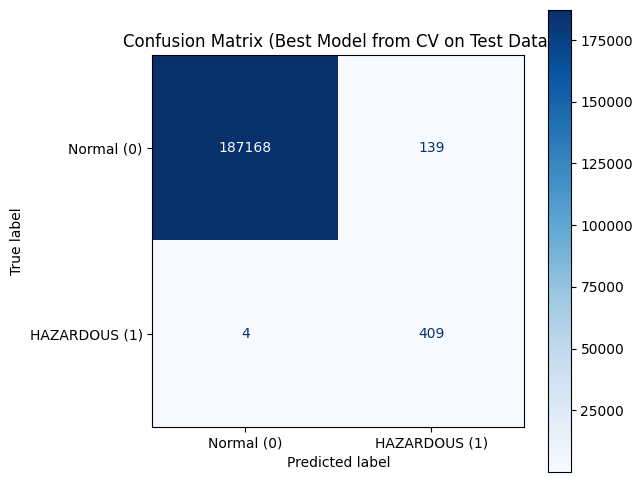

 تقرير الأداء لأفضل موديل على بيانات الـ Test:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    187307
           1       0.75      0.99      0.85       413

    accuracy                           1.00    187720
   macro avg       0.87      0.99      0.93    187720
weighted avg       1.00      1.00      1.00    187720



In [288]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# 1. تحديد الـ Hyperparameters اللي حابين نجربها ونقارن بينها عشان نطلع الأفضل
param_grid = {
    'model__max_depth': [6],
    'model__n_estimators': [ 300]
}

# 2. إعداد الـ Stratified K-Fold
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# 3. إعداد الـ GridSearchCV (هيعمل CV لكل تركيبة ويختار الأفضل بناءً على الـ roc_auc)
grid_search = GridSearchCV(
    estimator=xgb_pipeline,       # الـ Pipeline الخاص بك
    param_grid=param_grid,
    scoring='roc_auc',            # المقياس الأفضل للكويكبات الخطرة
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1
)

# 4. بدء التدريب والبحث عن أفضل موديل عبر الـ CV
print("جاري البحث عن أفضل Hyperparameters وتدريب الموديل باستخدام الـ CV...")
grid_search.fit(X_train_final, y_train_clean)

# 5. استخراج "أفضل موديل" تم التوصل إليه
best_xgb_model = grid_search.best_estimator_

print("=" * 50)
print(f"أفضل إعدادات وجدها الـ CV: {grid_search.best_params_}")
print(f"أفضل نتيجة ROC-AUC في الـ CV: {grid_search.best_score_:.5f}")
print("=" * 50)

# 6. التنبؤ على بيانات الـ Test الخارجية باستخدام "أفضل موديل" فقط
y_pred_best = best_xgb_model.predict(X_test_final)

# 7. حساب ورسم الـ Confusion Matrix
cm_best = confusion_matrix(y_test_clean, y_pred_best)

plt.figure(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=['Normal (0)', 'HAZARDOUS (1)'])
disp.plot(cmap=plt.cm.Blues, values_format='d', ax=plt.gca())
plt.title("Confusion Matrix (Best Model from CV on Test Data)")
plt.show()

# 8. طباعة تقرير الأداء الشامل
print("=" * 50)
print(" تقرير الأداء لأفضل موديل على بيانات الـ Test:")
print("=" * 50)
print(classification_report(y_test_clean, y_pred_best))

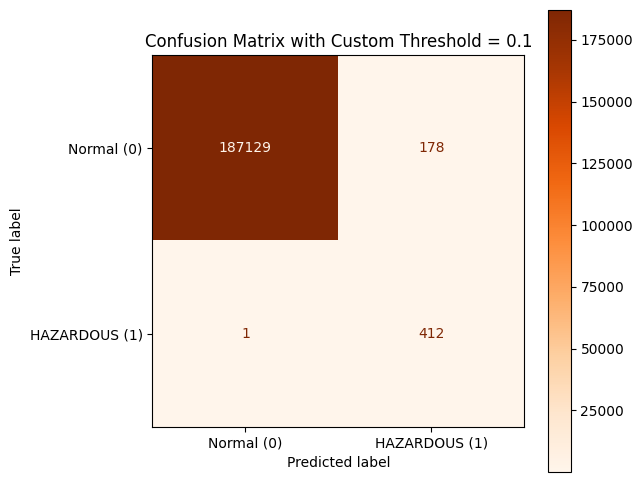

 نتائج الأداء عند Threshold = 0.1
              precision    recall  f1-score   support

           0     1.0000    0.9990    0.9995    187307
           1     0.6983    0.9976    0.8215       413

    accuracy                         0.9990    187720
   macro avg     0.8491    0.9983    0.9105    187720
weighted avg     0.9993    0.9990    0.9991    187720



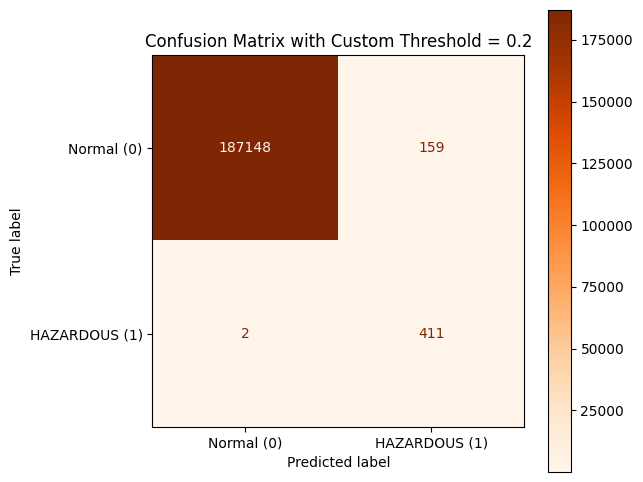

 نتائج الأداء عند Threshold = 0.2
              precision    recall  f1-score   support

           0     1.0000    0.9992    0.9996    187307
           1     0.7211    0.9952    0.8362       413

    accuracy                         0.9991    187720
   macro avg     0.8605    0.9972    0.9179    187720
weighted avg     0.9994    0.9991    0.9992    187720



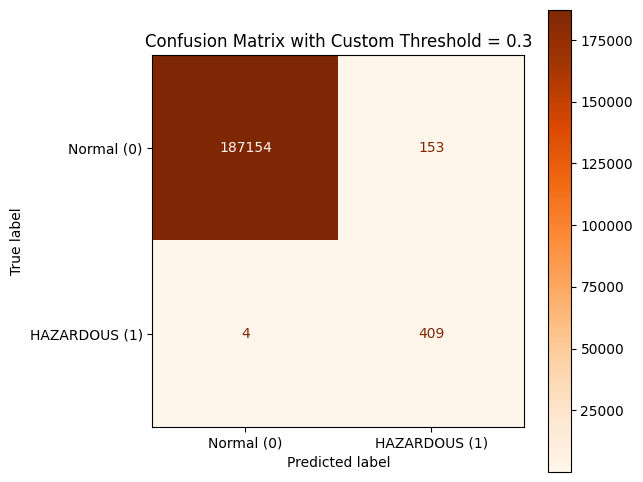

 نتائج الأداء عند Threshold = 0.3
              precision    recall  f1-score   support

           0     1.0000    0.9992    0.9996    187307
           1     0.7278    0.9903    0.8390       413

    accuracy                         0.9992    187720
   macro avg     0.8639    0.9947    0.9193    187720
weighted avg     0.9994    0.9992    0.9992    187720



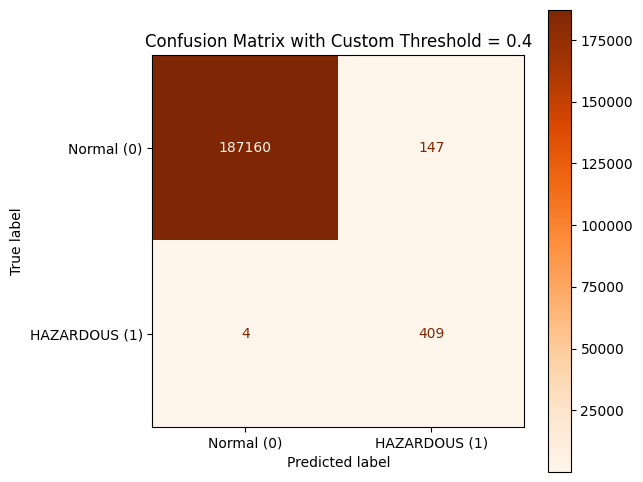

 نتائج الأداء عند Threshold = 0.4
              precision    recall  f1-score   support

           0     1.0000    0.9992    0.9996    187307
           1     0.7356    0.9903    0.8442       413

    accuracy                         0.9992    187720
   macro avg     0.8678    0.9948    0.9219    187720
weighted avg     0.9994    0.9992    0.9993    187720



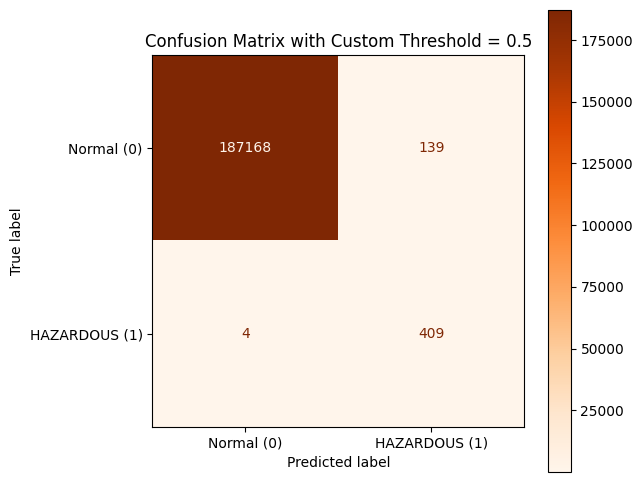

 نتائج الأداء عند Threshold = 0.5
              precision    recall  f1-score   support

           0     1.0000    0.9993    0.9996    187307
           1     0.7464    0.9903    0.8512       413

    accuracy                         0.9992    187720
   macro avg     0.8732    0.9948    0.9254    187720
weighted avg     0.9994    0.9992    0.9993    187720



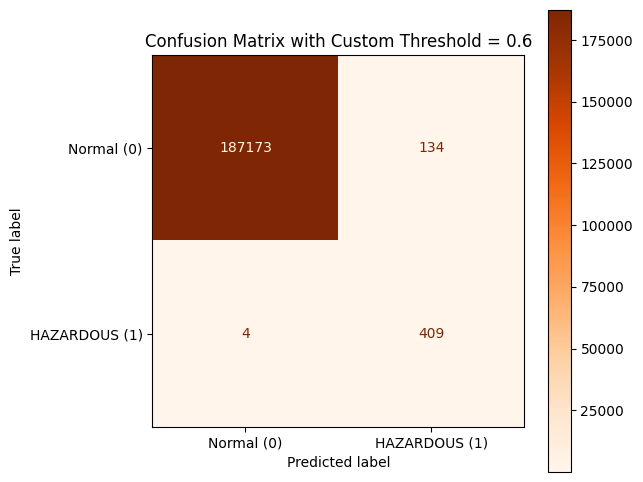

 نتائج الأداء عند Threshold = 0.6
              precision    recall  f1-score   support

           0     1.0000    0.9993    0.9996    187307
           1     0.7532    0.9903    0.8556       413

    accuracy                         0.9993    187720
   macro avg     0.8766    0.9948    0.9276    187720
weighted avg     0.9994    0.9993    0.9993    187720



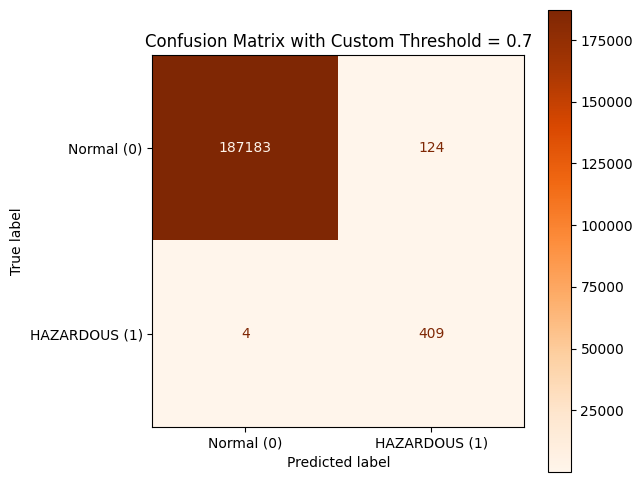

 نتائج الأداء عند Threshold = 0.7
              precision    recall  f1-score   support

           0     1.0000    0.9993    0.9997    187307
           1     0.7674    0.9903    0.8647       413

    accuracy                         0.9993    187720
   macro avg     0.8837    0.9948    0.9322    187720
weighted avg     0.9995    0.9993    0.9994    187720



In [297]:

import numpy as np
from sklearn.metrics import classification_report

# 1. استخراج الاحتمالات الخاصة بالفئة الإيجابية مرة واحدة
y_proba = best_xgb_model.predict_proba(X_test_final)[:, 1]

# 2. قائمة الـ Thresholds اللي حابب تجربها
thresholds_to_test = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

# 3. حلقة تكرارية لتجربة كل Threshold وطباعة تقرير الأداء الخاص به
for th in thresholds_to_test:
    # تحويل الاحتمالات بناءً على الـ Threshold الحالي
    y_pred_th = (y_proba >= th).astype(int)

    cm_custom = confusion_matrix(y_test_clean, y_pred_th)

    plt.figure(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_custom, display_labels=['Normal (0)', 'HAZARDOUS (1)'])
    disp.plot(cmap=plt.cm.Oranges, values_format='d', ax=plt.gca())
    plt.title(f"Confusion Matrix with Custom Threshold = {th}")
    plt.show()

    print("=" * 60)
    print(f" نتائج الأداء عند Threshold = {th}")
    print("=" * 60)
    print(classification_report(y_test_clean, y_pred_th, digits=4, zero_division=0))

In [ ]:
RANDOM_STATE=42

جاري البحث عن أفضل إعدادات لنموذج Logistic Regression باستخدام CV...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
أفضل إعدادات وجدها الـ CV: {'pca__n_components': 0.95}
أفضل نتيجة ROC-AUC في الـ CV: 0.99734


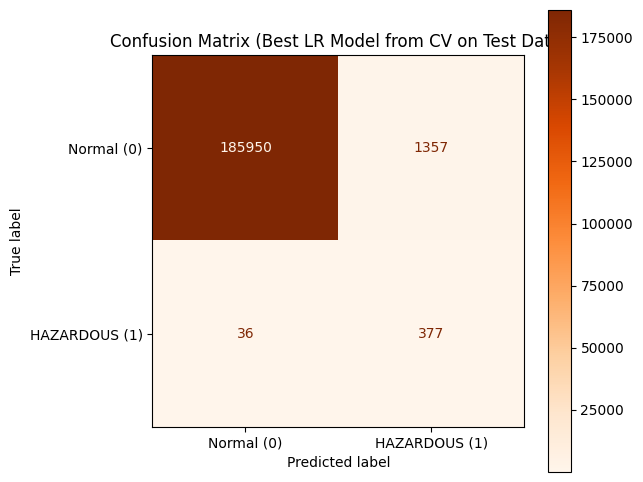

 تقرير الأداء لأفضل موديل Logistic Regression على بيانات الـ Test:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    187307
           1       0.22      0.91      0.35       413

    accuracy                           0.99    187720
   macro avg       0.61      0.95      0.67    187720
weighted avg       1.00      0.99      0.99    187720



In [289]:
#logaritmic

from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
PCA_VARIANCE=0.95
# 1. تعريف الـ Pipeline الذي يحتوي على PCA و SMOTE و Logistic Regression
lr_pipeline = ImbPipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("pca", PCA(
                n_components=PCA_VARIANCE,
                random_state=RANDOM_STATE
            )),
        ("smote", SMOTE(
                sampling_strategy=0.05,
                k_neighbors=5,
                random_state=RANDOM_STATE
            )),
        ("model",LogisticRegression(
                C=1.0,
                penalty="l2",
                solver="lbfgs",
                max_iter=1000,
                class_weight=None,
                random_state=RANDOM_STATE
            ))
    ]
)

# 2. تحديد المعلمات (Hyperparameters) التي ترغب في تجربتها والمقارنة بينها عبر الـ CV
# ملاحظة: يمكنك التحكم في نسب الـ SMOTE أو نسبة ضغط الـ PCA لمعرفة أيها يعطي أفضل نتيجة
param_grid = {
    'pca__n_components': [ 0.95],                  # تجربة نسب مختلفة للـ PCA

}

# 3. إعداد الـ Stratified K-Fold
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# 4. إعداد الـ GridSearchCV للبحث عن أفضل توليفة عبر الـ CV
grid_search_lr = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=param_grid,
    scoring='roc_auc',         # المقياس الأفضل للتعامل مع البيانات غير المتوازنة
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1
)

# 5. بدء البحث والتدريب الشامل
print("جاري البحث عن أفضل إعدادات لنموذج Logistic Regression باستخدام CV...")
grid_search_lr.fit(X_train_final, y_train_clean)

# 6. استخراج "أفضل موديل" تم التوصل إليه
best_lr_model = grid_search_lr.best_estimator_

print("=" * 50)
print(f"أفضل إعدادات وجدها الـ CV: {grid_search_lr.best_params_}")
print(f"أفضل نتيجة ROC-AUC في الـ CV: {grid_search_lr.best_score_:.5f}")
print("=" * 50)

# 7. التنبؤ على بيانات الـ Test الخارجية باستخدام "أفضل موديل" فقط
y_pred_lr_best = best_lr_model.predict(X_test_final)

# 8. حساب ورسم الـ Confusion Matrix
cm_lr_best = confusion_matrix(y_test_clean, y_pred_lr_best)

plt.figure(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr_best, display_labels=['Normal (0)', 'HAZARDOUS (1)'])
disp.plot(cmap=plt.cm.Oranges, values_format='d', ax=plt.gca()) # لون برتقالي لتمييزه عن موديل الـ XGBoost
plt.title("Confusion Matrix (Best LR Model from CV on Test Data)")
plt.show()

# 9. طباعة تقرير الأداء الشامل
print("=" * 50)
print(" تقرير الأداء لأفضل موديل Logistic Regression على بيانات الـ Test:")
print("=" * 50)
print(classification_report(y_test_clean, y_pred_lr_best))

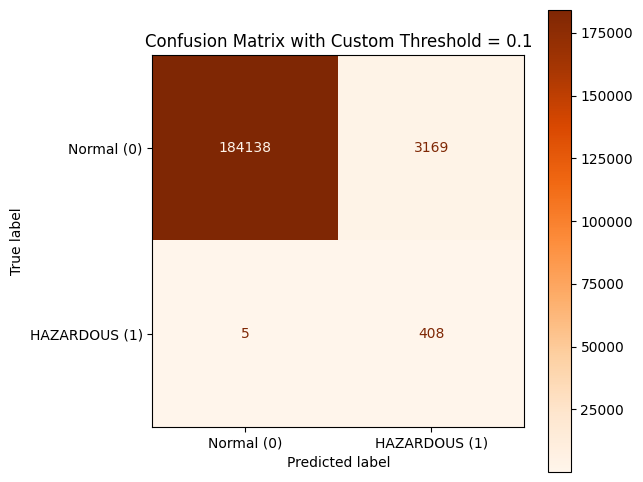

 نتائج الأداء عند Threshold = 0.1
              precision    recall  f1-score   support

           0     1.0000    0.9831    0.9915    187307
           1     0.1141    0.9879    0.2045       413

    accuracy                         0.9831    187720
   macro avg     0.5570    0.9855    0.5980    187720
weighted avg     0.9980    0.9831    0.9897    187720



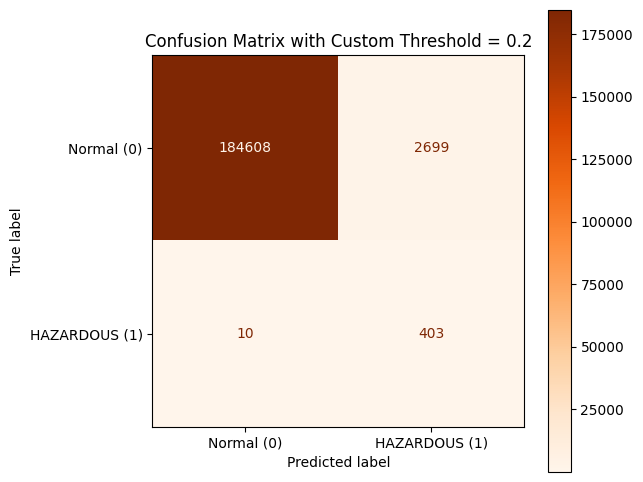

 نتائج الأداء عند Threshold = 0.2
              precision    recall  f1-score   support

           0     0.9999    0.9856    0.9927    187307
           1     0.1299    0.9758    0.2293       413

    accuracy                         0.9856    187720
   macro avg     0.5649    0.9807    0.6110    187720
weighted avg     0.9980    0.9856    0.9910    187720



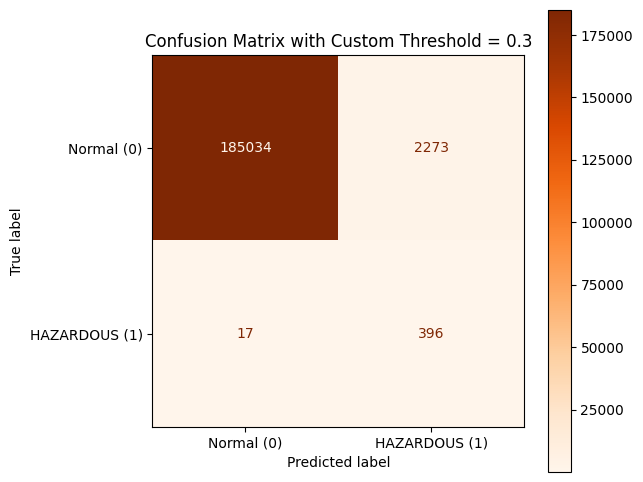

 نتائج الأداء عند Threshold = 0.3
              precision    recall  f1-score   support

           0     0.9999    0.9879    0.9939    187307
           1     0.1484    0.9588    0.2570       413

    accuracy                         0.9878    187720
   macro avg     0.5741    0.9734    0.6254    187720
weighted avg     0.9980    0.9878    0.9922    187720



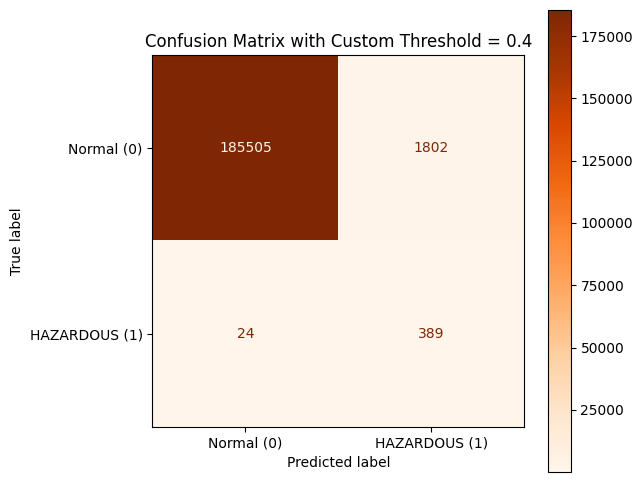

 نتائج الأداء عند Threshold = 0.4
              precision    recall  f1-score   support

           0     0.9999    0.9904    0.9951    187307
           1     0.1775    0.9419    0.2988       413

    accuracy                         0.9903    187720
   macro avg     0.5887    0.9661    0.6469    187720
weighted avg     0.9981    0.9903    0.9936    187720



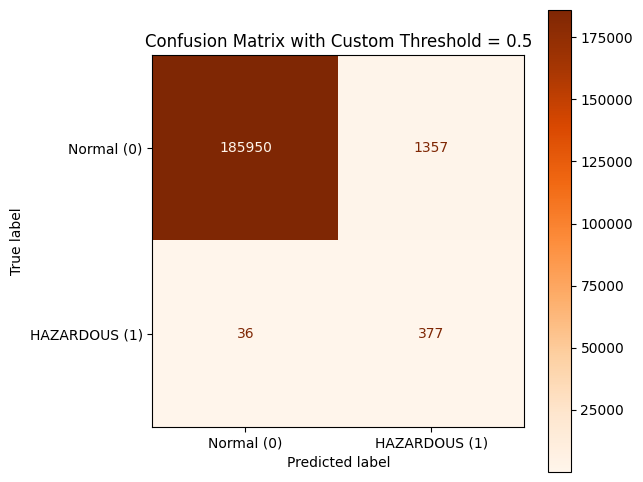

 نتائج الأداء عند Threshold = 0.5
              precision    recall  f1-score   support

           0     0.9998    0.9928    0.9963    187307
           1     0.2174    0.9128    0.3512       413

    accuracy                         0.9926    187720
   macro avg     0.6086    0.9528    0.6737    187720
weighted avg     0.9981    0.9926    0.9948    187720



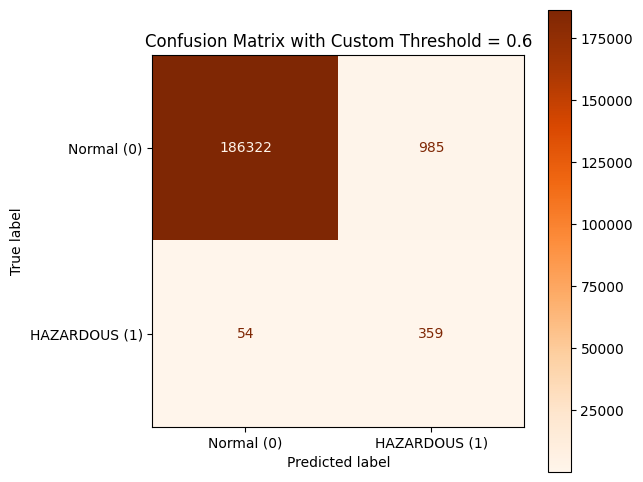

 نتائج الأداء عند Threshold = 0.6
              precision    recall  f1-score   support

           0     0.9997    0.9947    0.9972    187307
           1     0.2671    0.8692    0.4087       413

    accuracy                         0.9945    187720
   macro avg     0.6334    0.9320    0.7029    187720
weighted avg     0.9981    0.9945    0.9959    187720



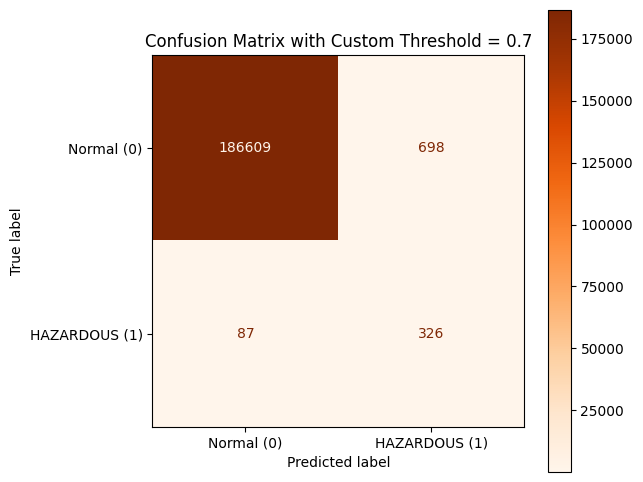

 نتائج الأداء عند Threshold = 0.7
              precision    recall  f1-score   support

           0     0.9995    0.9963    0.9979    187307
           1     0.3184    0.7893    0.4537       413

    accuracy                         0.9958    187720
   macro avg     0.6589    0.8928    0.7258    187720
weighted avg     0.9980    0.9958    0.9967    187720



In [301]:
import numpy as np
from sklearn.metrics import classification_report

# 1. استخراج الاحتمالات الخاصة بالفئة الإيجابية مرة واحدة
y_proba2 = best_lr_model.predict_proba(X_test_final)[:, 1]

# 2. قائمة الـ Thresholds اللي حابب تجربها
thresholds_to_test = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

# 3. حلقة تكرارية لتجربة كل Threshold وطباعة تقرير الأداء الخاص به
for th in thresholds_to_test:
    # تحويل الاحتمالات بناءً على الـ Threshold الحالي
    y_pred_th = (y_proba2 >= th).astype(int)

    cm_custom = confusion_matrix(y_test_clean, y_pred_th)

    plt.figure(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_custom, display_labels=['Normal (0)', 'HAZARDOUS (1)'])
    disp.plot(cmap=plt.cm.Oranges, values_format='d', ax=plt.gca())
    plt.title(f"Confusion Matrix with Custom Threshold = {th}")
    plt.show()

    print("=" * 60)
    print(f" نتائج الأداء عند Threshold = {th}")
    print("=" * 60)
    print(classification_report(y_test_clean, y_pred_th, digits=4, zero_division=0))

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# 1. تعريف الـ Pipeline الخاص بـ Random Forest (بدون PCA أو SMOTE)
rf_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=None,
                min_samples_leaf=2,
                max_features="sqrt",
                class_weight="balanced_subsample",
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

# 2. تحديد المعلمات (Hyperparameters) للبحث عنها عبر الـ CV واختيار الأفضل
param_grid = {
    'model__n_estimators': [ 300],
    'model__max_depth': [None],
    'model__min_samples_split': [2]
}

# 3. إعداد الـ Stratified K-Fold
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# 4. إعداد الـ GridSearchCV للبحث الذكي عبر الـ CV
grid_search_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    scoring='roc_auc',          # المقياس الأفضل للتعامل مع الكويكبات الخطرة
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1
)

# 5. بدء البحث والتدريب الشامل
print("جاري البحث عن أفضل إعدادات لنموذج Random Forest باستخدام CV...")
grid_search_rf.fit(X_train_final, y_train_clean)

# 6. استخراج "أفضل موديل" تم التوصل إليه
best_rf_model = grid_search_rf.best_estimator_

print("=" * 50)
print(f"أفضل إعدادات وجدها الـ CV: {grid_search_rf.best_params_}")
print(f"أفضل نتيجة ROC-AUC في الـ CV: {grid_search_rf.best_score_:.5f}")
print("=" * 50)

# 7. التنبؤ على بيانات الـ Test الخارجية باستخدام "أفضل موديل" فقط
y_pred_rf_best = best_rf_model.predict(X_test_final)

# 8. حساب ورسم الـ Confusion Matrix
cm_rf_best = confusion_matrix(y_test_clean, y_pred_rf_best)

plt.figure(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf_best, display_labels=['Normal (0)', 'HAZARDOUS (1)'])
disp.plot(cmap=plt.cm.Greens, values_format='d', ax=plt.gca()) # اخترنا اللون الأخضر لتمييز موديل الـ Random Forest
plt.title("Confusion Matrix (Best RF Model from CV on Test Data)")
plt.show()

# 9. طباعة تقرير الأداء الشامل
print("=" * 50)
print(" تقرير الأداء لأفضل موديل Random Forest على بيانات الـ Test:")
print("=" * 50)
print(classification_report(y_test_clean, y_pred_rf_best))

جاري البحث عن أفضل إعدادات لنموذج Random Forest باستخدام CV...
Fitting 5 folds for each of 1 candidates, totalling 5 fits


In [ ]:

# 1. استخراج الاحتمالات الخاصة بالفئة الإيجابية مرة واحدة
y_proba = best_rf_model.predict_proba(X_test_final)[:, 1]

# 2. قائمة الـ Thresholds اللي حابب تجربها
thresholds_to_test = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

# 3. حلقة تكرارية لتجربة كل Threshold وطباعة تقرير الأداء الخاص به
for th in thresholds_to_test:
    # تحويل الاحتمالات بناءً على الـ Threshold الحالي
    y_pred_th = (y_proba >= th).astype(int)

    cm_custom = confusion_matrix(y_test_clean, y_pred_th)

    plt.figure(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_custom, display_labels=['Normal (0)', 'HAZARDOUS (1)'])
    disp.plot(cmap=plt.cm.Oranges, values_format='d', ax=plt.gca())
    plt.title(f"Confusion Matrix with Custom Threshold = {th}")
    plt.show()

    print("=" * 60)
    print(f" نتائج الأداء عند Threshold = {th}")
    print("=" * 60)
    print(classification_report(y_test_clean, y_pred_th, digits=4, zero_division=0))